# K0S-constrained additive-curvature DNN

This notebook fits one **charge-independent additive signed-curvature correction** per TPC side:

\[
\kappa_{\rm rec}=q\frac{0.003B}{p_T},
\qquad
\kappa_{\rm corr}=\kappa_{\rm rec}+\Delta\kappa_{\rm side}(\phi_{\rm ref},\eta).
\]

The same \(\Delta\kappa\) is used for both charges. Since reconstructed signed curvature changes sign with charge, one common curvature correction naturally produces opposite fractional momentum effects:

\[
p_{T,\rm corr}=\frac{0.003B}{|\kappa_{\rm corr}|},
\qquad
s=\frac{p_{T,\rm corr}}{p_T}.
\]

The DNN inputs are only \(\sin\phi_{\rm ref}\), \(\cos\phi_{\rm ref}\), and \(\eta\). There is no charge or \(p_T\) input. The reference azimuth is the spatial azimuth where the measured helix first crosses a configurable radius inside the TPC.

The notebook performs a 12-CPU hyperparameter search, trains a final ensemble, writes physical \(\Delta\kappa(\phi,\eta)\) maps, and derives charge-dependent momentum-scale maps from them.

A second output converts the physical reference-radius map into a standard beam-origin map indexed by \(p_T\), momentum \(\phi\) at the production vertex, \(\eta\), charge, and side. An exact per-track converter is also provided for displaced daughters.


This version balances the total training contribution of six reconstructed \(K^0_S\) \(p_T\) bins while using shrinkage and a hard weight cap to avoid high-\(p_T\) statistical fluctuations dominating the fit. Validation remains unweighted and is plotted separately in every requested \(p_T\) bin.


This version replaces binned \(K^0_S\)-candidate weighting with a smooth,
tempered inverse-density weight derived from the individual daughter-track
\(p_T\) spectrum. The requested \(K^0_S\) \(p_T\) bins remain as unweighted
validation diagnostics only.


In [1]:
from pathlib import Path
from itertools import product
from array import array
import copy
import json
import math
import os
import random
import time
import traceback

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

from scipy.optimize import minimize

try:
    from joblib import Parallel, delayed, parallel_backend
    joblib_available = True
except ImportError:
    joblib_available = False

try:
    import ROOT as root
except ImportError:
    root = None

seed = 12345
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

csv_file = Path("/media/yoren/T7_Shield/sPHENIX/tracking/csvs/fit_k0s_pp_v1.csv")
work_dir = Path('output/k0s_momentum_scale_map_plots_cut03_new/')
work_dir.mkdir(parents=True, exist_ok=True)

selection_name = 'cut03'
training_parity = 0
validation_parity = 1 - training_parity

pdg_kshort_mass = 0.497611
pion_mass = 0.13957039

magnetic_field_tesla = 1.4
curvature_conversion = 0.003  # pT[GeV], B[T], kappa[1/cm]
reference_radius_cm = 53.0

validation_mass_minimum = 0.47
validation_mass_maximum = 0.53


# Requested K0S-pT bins are retained for unweighted validation QA.
kshort_pt_bin_edges = np.array([
    0.5,
    0.8,
    1.1,
    1.4,
    1.8,
    2.2,
    3.0,
], dtype=np.float64)

# Training weights are derived smoothly from the single-daughter
# track-pT spectrum, separately for each TPC side.
use_smooth_track_pt_reweighting = True

track_pt_weight_minimum = 0.20
track_pt_weight_maximum = 10.00

# Density is estimated in log(pT), which is more appropriate for
# the steeply falling daughter spectrum.
track_pt_density_number_of_bins = 80
track_pt_density_smoothing_sigma_bins = 2.0

# w(pT) is proportional to density(pT)^(-power).
# 0.5 is deliberately gentler than full inverse-density weighting.
track_pt_weight_power = 0.75

# Prevent the estimated density from approaching zero in the tails.
track_pt_density_floor_fraction = 0.05

minimum_track_weight = 0.35
maximum_track_weight = 5.00

# The pair likelihood has one scalar value, so the two daughter
# weights are combined symmetrically. Geometric mean is less extreme
# than a product or arithmetic mean when only one daughter is rare.
pair_weight_combination = "geometric_mean"

requested_cpus = 12
threads_per_worker = 1
parallel_jobs = min(requested_cpus, os.cpu_count() or 1)

search_mode = 'random'
maximum_trials_per_side = 6
maximum_search_epochs = 300
search_patience = 35

number_of_ensemble_models = 3
maximum_final_epochs = 1000
final_patience = 60

print('PyTorch:', torch.__version__)
print('Parallel workers:', parallel_jobs)

Welcome to JupyROOT 6.30/06
PyTorch: 2.9.0+cu128
Parallel workers: 12


## Helix propagation to the reference radius

For each daughter, the measured transverse helix is propagated from the pair secondary vertex to its first forward intersection with \(r=r_{\rm ref}\). The network uses the spatial azimuth of that intersection, not the momentum azimuth at the secondary vertex.

In [2]:
TWO_PI = 2.0 * math.pi

def wrap_phi(phi):
    return (np.asarray(phi) + math.pi) % TWO_PI - math.pi

def propagate_to_reference_radius(x0, y0, phi0, pt, charge, rref):
    """First forward transverse-helix intersection with r = rref."""
    x0 = np.asarray(x0, dtype=float)
    y0 = np.asarray(y0, dtype=float)
    phi0 = np.asarray(phi0, dtype=float)
    pt = np.asarray(pt, dtype=float)
    charge = np.asarray(charge, dtype=float)

    # For Bz > 0: d(phi_momentum)/ds_T = -q * 0.003 * B / pT.
    omega = -charge * curvature_conversion * magnetic_field_tesla / np.clip(pt, 1e-6, None)

    xc = x0 - np.sin(phi0) / omega
    yc = y0 + np.cos(phi0) / omega
    rc = np.abs(1.0 / omega)
    d = np.hypot(xc, yc)

    valid = (
        np.isfinite(d)
        & (d > 1e-9)
        & (rref <= d + rc)
        & (rref >= np.abs(d - rc))
    )

    dsafe = np.where(valid, d, 1.0)
    a = (rref**2 - rc**2 + dsafe**2) / (2.0 * dsafe)
    h2 = rref**2 - a**2
    valid &= h2 >= -1e-8
    h = np.sqrt(np.clip(h2, 0.0, None))

    ux, uy = xc / dsafe, yc / dsafe
    bx, by = a * ux, a * uy
    px, py = -uy, ux

    xa, ya = bx + h * px, by + h * py
    xb, yb = bx - h * px, by - h * py

    def tangent_phi(x, y):
        return np.arctan2(omega * (x - xc), -omega * (y - yc))

    phia = tangent_phi(xa, ya)
    phib = tangent_phi(xb, yb)

    def forward_path(phi_target):
        dphi_pos = np.mod(phi_target - phi0, TWO_PI)
        dphi_neg = -np.mod(phi0 - phi_target, TWO_PI)
        dphi = np.where(omega > 0.0, dphi_pos, dphi_neg)
        path = dphi / omega
        return np.where(path > 1e-8, path, np.inf)

    sa = forward_path(phia)
    sb = forward_path(phib)
    choose_a = sa <= sb

    x = np.where(choose_a, xa, xb)
    y = np.where(choose_a, ya, yb)
    s = np.where(choose_a, sa, sb)
    phi_momentum_ref = np.where(choose_a, phia, phib)

    valid &= np.isfinite(s)

    return {
        'phi_position_ref': np.where(valid, wrap_phi(np.arctan2(y, x)), np.nan),
        'phi_momentum_ref': np.where(valid, wrap_phi(phi_momentum_ref), np.nan),
        'path_to_ref': np.where(valid, s, np.nan),
        'valid': valid,
    }

Selected propagated candidates: 25042
side  entry_parity
0     0               6878
      1               6621
1     0               5791
      1               5752
dtype: int64


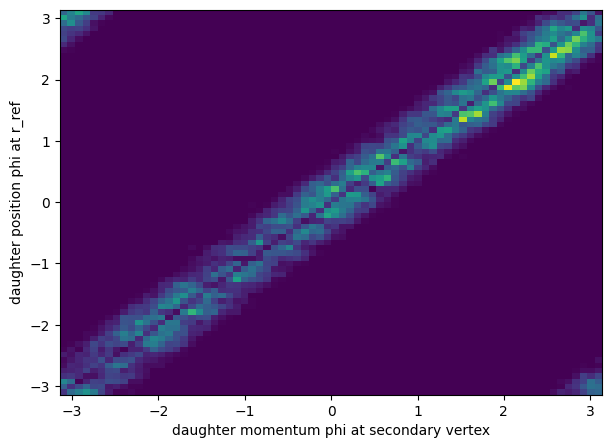

In [3]:
data = pd.read_csv(csv_file)


if "kshort_pt" not in data.columns:
    raise KeyError(
        "The CSV does not contain kshort_pt. "
        "Regenerate it with the updated K0S CSV exporter."
    )

if selection_name == 'cut03':
    selection_flag = data['pass_cut03'].astype(bool)
elif selection_name == 'cut07':
    selection_flag = data['pass_cut07'].astype(bool)
else:
    raise ValueError("selection_name must be 'cut03' or 'cut07'")

selected = data.loc[
    selection_flag
    & data['pass_pion_pid'].astype(bool)
    & data['pass_signed_delta_phi'].astype(bool)
    & data['same_side'].astype(bool)
    & (data['mass_before'] >= validation_mass_minimum)
    & (data['mass_before'] <= validation_mass_maximum)
].copy()

selected['side'] = selected['side1'].astype(int)

prop1 = propagate_to_reference_radius(
    selected['pca_x'], selected['pca_y'], selected['phi1'],
    selected['pt1'], selected['charge1'], reference_radius_cm,
)
prop2 = propagate_to_reference_radius(
    selected['pca_x'], selected['pca_y'], selected['phi2'],
    selected['pt2'], selected['charge2'], reference_radius_cm,
)

selected['phi1_ref'] = prop1['phi_position_ref']
selected['phi2_ref'] = prop2['phi_position_ref']
selected['path1_to_ref'] = prop1['path_to_ref']
selected['path2_to_ref'] = prop2['path_to_ref']
selected = selected.loc[prop1['valid'] & prop2['valid']].copy()

print('Selected propagated candidates:', len(selected))
print(selected.groupby(['side', 'entry_parity']).size())

fig, ax = plt.subplots(figsize=(7, 5))
ax.hist2d(
    selected['phi1'], selected['phi1_ref'],
    bins=(72, 72),
    range=((-math.pi, math.pi), (-math.pi, math.pi)),
)
ax.set_xlabel('daughter momentum phi at secondary vertex')
ax.set_ylabel('daughter position phi at r_ref')
plt.show()

## Conventional mass prefit

For each side and tested training mass window, the raw mass is first fitted with a truncated Gaussian plus normalized linear background. The DNN keeps the fitted signal fraction, width, and background slope fixed. Its signal mean is centered at the PDG mass.

In [4]:
SQRT2 = math.sqrt(2.0)

def normal_cdf(x):
    return 0.5 * (1.0 + math.erf(float(x) / SQRT2))

def mass_pdf_numpy(mass, fraction, mean, sigma, slope, mmin, mmax):
    mass = np.asarray(mass, dtype=float)

    norm = sigma * math.sqrt(2.0 * math.pi) * max(
        normal_cdf((mmax - mean) / sigma)
        - normal_cdf((mmin - mean) / sigma),
        1e-12,
    )

    signal = np.exp(-0.5 * ((mass - mean) / sigma) ** 2) / norm
    x = (2.0 * mass - mmax - mmin) / (mmax - mmin)
    background = np.clip((1.0 + slope * x) / (mmax - mmin), 1e-12, None)
    return fraction * signal + (1.0 - fraction) * background

def fit_mass_model(masses, mmin, mmax):
    masses = np.asarray(masses, dtype=float)
    masses = masses[(masses >= mmin) & (masses <= mmax)]

    def nll(pars):
        f, mean, sigma, slope = pars
        pdf = mass_pdf_numpy(masses, f, mean, sigma, slope, mmin, mmax)
        return -np.sum(np.log(np.clip(pdf, 1e-15, None)))

    result = minimize(
        nll,
        x0=[0.55, 0.495, 0.009, 0.0],
        method='L-BFGS-B',
        bounds=[
            (0.05, 0.95),
            (0.475, 0.515),
            (0.003, 0.025),
            (-0.90, 0.90),
        ],
    )

    f, mean, sigma, slope = result.x
    return {
        'signal_fraction': float(f),
        'raw_peak_mean': float(mean),
        'signal_sigma': float(sigma),
        'background_slope': float(slope),
        'success': bool(result.success),
        'entries': int(len(masses)),
        'mass_minimum': float(mmin),
        'mass_maximum': float(mmax),
    }

training_mass_half_width_values = [0.030, 0.045, 0.060]
mass_models = {0: {}, 1: {}}

for side in [0, 1]:
    train_side = selected.loc[
        (selected['side'] == side)
        & (selected['entry_parity'] == training_parity)
    ]

    for half_width in training_mass_half_width_values:
        model = fit_mass_model(
            train_side['mass_before'],
            pdg_kshort_mass - half_width,
            pdg_kshort_mass + half_width,
        )
        mass_models[side][half_width] = model
        print('side', side, 'half-width', half_width, model)

side 0 half-width 0.03 {'signal_fraction': 0.5911334723177214, 'raw_peak_mean': 0.49837530499087984, 'signal_sigma': 0.008477965230284356, 'background_slope': 0.438274940548066, 'success': True, 'entries': 6733, 'mass_minimum': 0.467611, 'mass_maximum': 0.527611}
side 0 half-width 0.045 {'signal_fraction': 0.95, 'raw_peak_mean': 0.5000779816582156, 'signal_sigma': 0.012783295188647388, 'background_slope': 0.9, 'success': True, 'entries': 6878, 'mass_minimum': 0.45261100000000004, 'mass_maximum': 0.5426110000000001}
side 0 half-width 0.06 {'signal_fraction': 0.95, 'raw_peak_mean': 0.500200842337305, 'signal_sigma': 0.012833489411082815, 'background_slope': 0.8986159537548056, 'success': True, 'entries': 6878, 'mass_minimum': 0.437611, 'mass_maximum': 0.5576110000000001}
side 1 half-width 0.03 {'signal_fraction': 0.5990715925702056, 'raw_peak_mean': 0.49813713058973247, 'signal_sigma': 0.00802781074884618, 'background_slope': 0.4149724307930204, 'success': True, 'entries': 5690, 'mass_mi


## Smooth daughter-track \(p_T\) reweighting

The additive-curvature model acts on individual tracks, so the balancing
variable should be each daughter track \(p_T\), not the reconstructed
\(K^0_S\) candidate \(p_T\).

For every side, the notebook estimates the training daughter spectrum
smoothly in \(\log p_T\):

\[
\rho_{\rm side}(\log p_T).
\]

The single-track weight is

\[
w_{\rm track}(p_T)
\propto
\rho_{\rm side}(\log p_T)^{-\alpha},
\]

with a default tempered exponent

\[
\alpha=0.5.
\]

This is intentionally weaker than full inverse-density weighting because:

- high-\(p_T\) tracks are statistically rare;
- an additive \(\Delta\kappa\) already produces a larger fractional effect at high \(p_T\);
- full flattening would give the high-\(p_T\) tail too much leverage.

The two daughter weights are combined using a geometric mean:

\[
w_{\rm pair}
=
\sqrt{
w_{\rm track}(p_{T,1})
w_{\rm track}(p_{T,2})
}.
\]

Weights are clipped and normalized to unit mean. Only the training loss is
weighted; all validation mass plots remain unweighted.


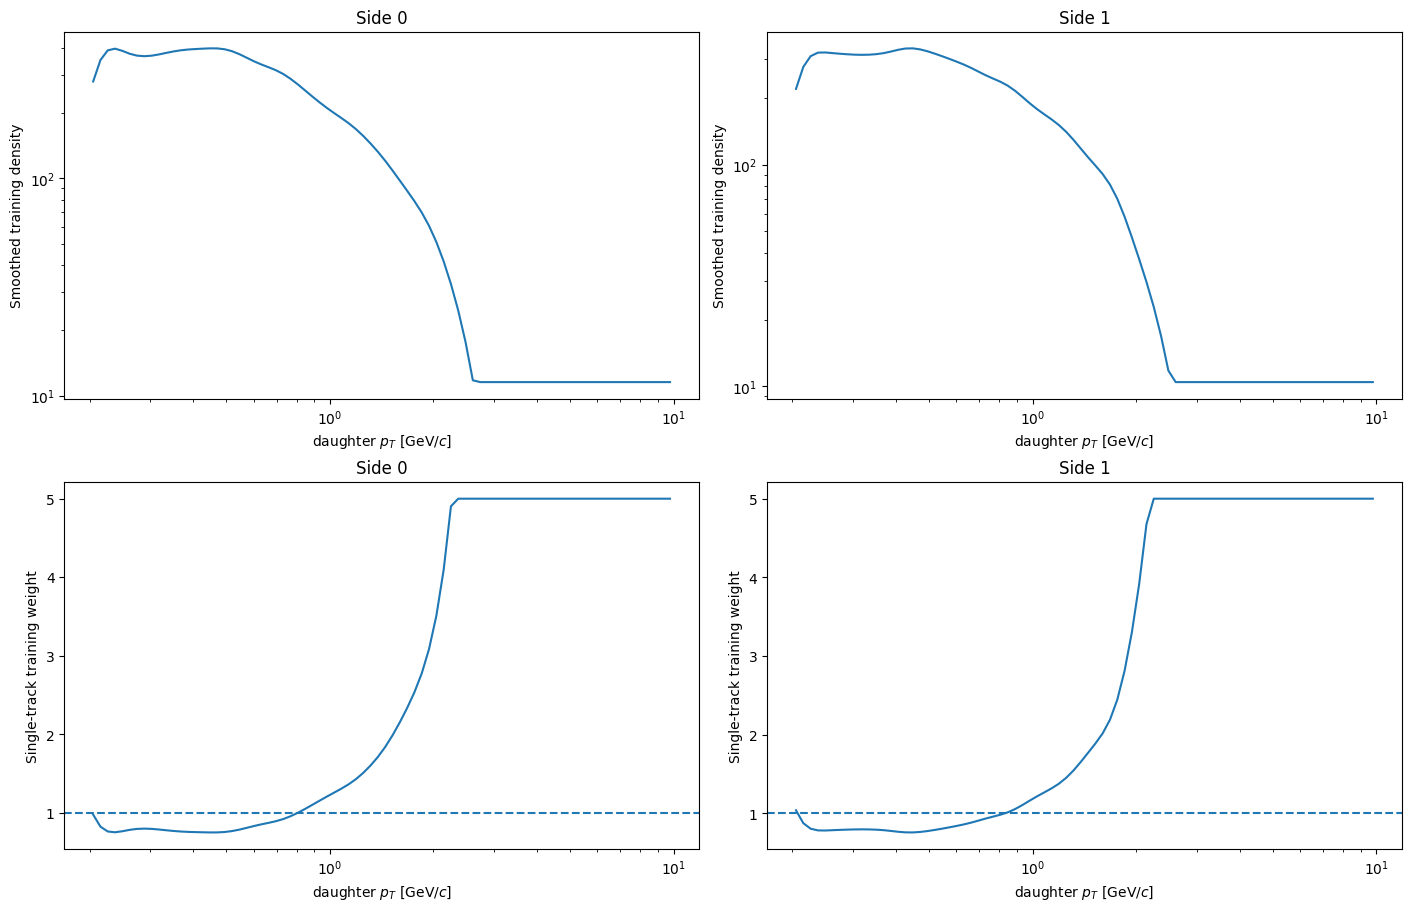

In [5]:

# ============================================================
# Smooth side-specific daughter-track pT density and weights
# ============================================================

def gaussian_kernel_1d(
    sigma_bins,
    truncate=4.0,
):
    radius = max(
        1,
        int(
            math.ceil(
                truncate * sigma_bins
            )
        ),
    )

    offsets = np.arange(
        -radius,
        radius + 1,
        dtype=np.float64,
    )

    kernel = np.exp(
        -0.5
        * (
            offsets / sigma_bins
        ) ** 2
    )

    kernel /= np.sum(kernel)

    return kernel


def build_track_pt_weight_model(
    frame,
):
    daughter_pt = np.concatenate([
        frame["pt1"].to_numpy(
            dtype=np.float64
        ),
        frame["pt2"].to_numpy(
            dtype=np.float64
        ),
    ])

    daughter_pt = daughter_pt[
        np.isfinite(daughter_pt)
        & (
            daughter_pt
            >= track_pt_weight_minimum
        )
        & (
            daughter_pt
            <= track_pt_weight_maximum
        )
    ]

    log_minimum = math.log(
        track_pt_weight_minimum
    )

    log_maximum = math.log(
        track_pt_weight_maximum
    )

    log_edges = np.linspace(
        log_minimum,
        log_maximum,
        track_pt_density_number_of_bins
        + 1,
        dtype=np.float64,
    )

    log_centers = 0.5 * (
        log_edges[:-1]
        + log_edges[1:]
    )

    counts, _ = np.histogram(
        np.log(daughter_pt),
        bins=log_edges,
    )

    kernel = gaussian_kernel_1d(
        track_pt_density_smoothing_sigma_bins
    )

    smooth_counts = np.convolve(
        counts.astype(np.float64),
        kernel,
        mode="same",
    )

    positive = smooth_counts[
        smooth_counts > 0
    ]

    reference_density = (
        float(np.median(positive))
        if len(positive)
        else 1.0
    )

    density_floor = (
        track_pt_density_floor_fraction
        * max(
            reference_density,
            1.0,
        )
    )

    smooth_density = np.maximum(
        smooth_counts,
        density_floor,
    )

    raw_weights = (
        reference_density
        / smooth_density
    ) ** track_pt_weight_power

    raw_weights = np.clip(
        raw_weights,
        minimum_track_weight,
        maximum_track_weight,
    )

    # Normalize using the actual training daughter population.
    interpolated_population_weights = np.interp(
        np.log(daughter_pt),
        log_centers,
        raw_weights,
        left=raw_weights[0],
        right=raw_weights[-1],
    )

    normalization = float(
        np.mean(
            interpolated_population_weights
        )
    )

    if normalization > 0:
        raw_weights /= normalization

    raw_weights = np.clip(
        raw_weights,
        minimum_track_weight,
        maximum_track_weight,
    )

    return {
        "log_pt_centers": log_centers,
        "pt_centers": np.exp(
            log_centers
        ),
        "raw_counts": counts,
        "smooth_density": smooth_density,
        "track_weights": raw_weights,
        "number_of_tracks": int(
            len(daughter_pt)
        ),
    }


track_pt_weight_models = {}

for side in [0, 1]:
    training_frame = selected.loc[
        (selected["side"] == side)
        & (
            selected["entry_parity"]
            == training_parity
        )
    ].copy()

    track_pt_weight_models[side] = (
        build_track_pt_weight_model(
            training_frame
        )
    )


def evaluate_single_track_pt_weights(
    side,
    pt_values,
):
    pt_values = np.asarray(
        pt_values,
        dtype=np.float64,
    )

    model = track_pt_weight_models[
        int(side)
    ]

    safe_pt = np.clip(
        pt_values,
        track_pt_weight_minimum,
        track_pt_weight_maximum,
    )

    weights = np.interp(
        np.log(safe_pt),
        model["log_pt_centers"],
        model["track_weights"],
        left=model["track_weights"][0],
        right=model["track_weights"][-1],
    )

    if not use_smooth_track_pt_reweighting:
        weights = np.ones_like(
            weights
        )

    return np.clip(
        weights,
        minimum_track_weight,
        maximum_track_weight,
    )


def calculate_smooth_pair_weights(
    frame,
    side,
):
    weight1 = evaluate_single_track_pt_weights(
        side,
        frame["pt1"].to_numpy(
            dtype=np.float64
        ),
    )

    weight2 = evaluate_single_track_pt_weights(
        side,
        frame["pt2"].to_numpy(
            dtype=np.float64
        ),
    )

    if (
        pair_weight_combination
        == "geometric_mean"
    ):
        pair_weights = np.sqrt(
            weight1 * weight2
        )
    elif (
        pair_weight_combination
        == "arithmetic_mean"
    ):
        pair_weights = 0.5 * (
            weight1 + weight2
        )
    elif (
        pair_weight_combination
        == "harmonic_mean"
    ):
        pair_weights = (
            2.0 * weight1 * weight2
            / np.clip(
                weight1 + weight2,
                1.0e-12,
                None,
            )
        )
    else:
        raise ValueError(
            "Unknown pair_weight_combination: "
            f"{pair_weight_combination}"
        )

    mean_weight = float(
        np.mean(pair_weights)
    )

    if mean_weight > 0:
        pair_weights /= mean_weight

    pair_weights = np.clip(
        pair_weights,
        minimum_track_weight,
        maximum_track_weight,
    )

    return {
        "pair_weights": (
            pair_weights.astype(
                np.float32
            )
        ),
        "track1_weights": weight1,
        "track2_weights": weight2,
    }


# Smooth-density and weight QA.
figure, axes = plt.subplots(
    2,
    2,
    figsize=(14, 9),
    constrained_layout=True,
)

for side in [0, 1]:
    model = track_pt_weight_models[
        side
    ]

    axes[0, side].plot(
        model["pt_centers"],
        model["smooth_density"],
    )

    axes[0, side].set_xscale(
        "log"
    )

    axes[0, side].set_yscale(
        "log"
    )

    axes[0, side].set_xlabel(
        r"daughter $p_T$ [GeV/$c$]"
    )

    axes[0, side].set_ylabel(
        "Smoothed training density"
    )

    axes[0, side].set_title(
        f"Side {side}"
    )

    axes[1, side].plot(
        model["pt_centers"],
        model["track_weights"],
    )

    axes[1, side].axhline(
        1.0,
        linestyle="--",
    )

    axes[1, side].set_xscale(
        "log"
    )

    axes[1, side].set_xlabel(
        r"daughter $p_T$ [GeV/$c$]"
    )

    axes[1, side].set_ylabel(
        "Single-track training weight"
    )

    axes[1, side].set_title(
        f"Side {side}"
    )

plt.show()


## Additive-curvature network

The network output is bounded as

\[
\Delta\kappa=\Delta\kappa_{\max}\tanh(y_{\rm raw}).
\]

A typical reconstructed curvature at \(p_T=1\ \mathrm{GeV}/c\) is \(4.2\times10^{-3}\ \mathrm{cm}^{-1}\). A 2% curvature correction is therefore about \(8.4\times10^{-5}\ \mathrm{cm}^{-1}\), so the search limits are centered around \(10^{-4}\ \mathrm{cm}^{-1}\).

In [6]:
def make_features(phi_ref, eta):
    return np.column_stack([
        np.sin(phi_ref),
        np.cos(phi_ref),
        eta,
    ]).astype(np.float32)

class PairDataset(Dataset):
    def __init__(
        self,
        frame,
        candidate_weights=None,
    ):
        self.f1 = torch.from_numpy(
            make_features(
                frame["phi1_ref"],
                frame["eta1"],
            )
        )

        self.f2 = torch.from_numpy(
            make_features(
                frame["phi2_ref"],
                frame["eta2"],
            )
        )

        self.q1 = torch.from_numpy(
            frame["charge1"].to_numpy(
                np.float32
            )
        )

        self.q2 = torch.from_numpy(
            frame["charge2"].to_numpy(
                np.float32
            )
        )

        self.pt1 = torch.from_numpy(
            frame["pt1"].to_numpy(
                np.float32
            )
        )

        self.pt2 = torch.from_numpy(
            frame["pt2"].to_numpy(
                np.float32
            )
        )

        self.p1 = torch.from_numpy(
            frame[
                ["px1", "py1", "pz1"]
            ].to_numpy(np.float32)
        )

        self.p2 = torch.from_numpy(
            frame[
                ["px2", "py2", "pz2"]
            ].to_numpy(np.float32)
        )

        self.mass = torch.from_numpy(
            frame["mass_before"].to_numpy(
                np.float32
            )
        )

        self.kshort_pt = torch.from_numpy(
            frame["kshort_pt"].to_numpy(
                np.float32
            )
        )

        if candidate_weights is None:
            candidate_weights = np.ones(
                len(frame),
                dtype=np.float32,
            )

        self.weight = torch.from_numpy(
            np.asarray(
                candidate_weights,
                dtype=np.float32,
            )
        )

    def __len__(self):
        return len(self.mass)

    def __getitem__(self, i):
        return {
            "f1": self.f1[i],
            "f2": self.f2[i],
            "q1": self.q1[i],
            "q2": self.q2[i],
            "pt1": self.pt1[i],
            "pt2": self.pt2[i],
            "p1": self.p1[i],
            "p2": self.p2[i],
            "mass": self.mass[i],
            "kshort_pt": self.kshort_pt[i],
            "weight": self.weight[i],
        }

class CurvatureNetwork(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        layers = []
        width = 3

        for _ in range(int(cfg['hidden_layers'])):
            layers += [
                nn.Linear(width, int(cfg['hidden_width'])),
                nn.SiLU(),
                nn.Dropout(float(cfg['dropout_probability'])),
            ]
            width = int(cfg['hidden_width'])

        self.trunk = nn.Sequential(*layers)
        self.output = nn.Linear(width, 1)
        self.max_delta = float(cfg['maximum_delta_curvature'])

        nn.init.zeros_(self.output.weight)
        nn.init.zeros_(self.output.bias)

    def delta_kappa(self, features):
        return self.max_delta * torch.tanh(self.output(self.trunk(features))[:, 0])

def corrected_track(model, features, charge, pt, momentum):
    delta = model.delta_kappa(features)
    conversion = curvature_conversion * magnetic_field_tesla
    kappa_rec = charge * conversion / torch.clamp(pt, min=1e-6)
    kappa_corr = kappa_rec + delta
    pt_corr = conversion / torch.clamp(torch.abs(kappa_corr), min=2e-4)
    scale = pt_corr / torch.clamp(pt, min=1e-6)
    return delta, scale, scale[:, None] * momentum

def invariant_mass(momentum1, momentum2, mass1=pion_mass, mass2=pion_mass):
    e1 = torch.sqrt(torch.sum(momentum1**2, dim=1) + mass1**2)
    e2 = torch.sqrt(torch.sum(momentum2**2, dim=1) + mass2**2)
    total = momentum1 + momentum2
    m2 = (e1 + e2)**2 - torch.sum(total**2, dim=1)
    return torch.sqrt(torch.clamp(m2, min=0.0))

In [7]:
def weighted_mean(values, weights):
    weights = torch.clamp(
        weights,
        min=0.0,
    )

    return torch.sum(
        values * weights
    ) / torch.clamp(
        torch.sum(weights),
        min=1.0e-12,
    )


def mass_nll_torch(mass, cfg):
    f = float(
        cfg["signal_fraction"]
    )

    sigma = float(
        cfg["signal_sigma"]
    )

    slope = float(
        cfg["background_slope"]
    )

    mmin = float(
        cfg["training_mass_minimum"]
    )

    mmax = float(
        cfg["training_mass_maximum"]
    )

    lower = 0.5 * (
        1.0
        + math.erf(
            (
                mmin
                - pdg_kshort_mass
            )
            / (
                math.sqrt(2.0)
                * sigma
            )
        )
    )

    upper = 0.5 * (
        1.0
        + math.erf(
            (
                mmax
                - pdg_kshort_mass
            )
            / (
                math.sqrt(2.0)
                * sigma
            )
        )
    )

    norm = (
        sigma
        * math.sqrt(
            2.0 * math.pi
        )
        * max(
            upper - lower,
            1.0e-12,
        )
    )

    signal = torch.exp(
        -0.5
        * (
            (
                mass
                - pdg_kshort_mass
            )
            / sigma
        ) ** 2
    ) / norm

    x = (
        2.0 * mass
        - mmax
        - mmin
    ) / (
        mmax - mmin
    )

    background = torch.clamp(
        (
            1.0
            + slope * x
        ) / (
            mmax - mmin
        ),
        min=1.0e-12,
    )

    probability = (
        f * signal
        + (1.0 - f)
        * background
    )

    # Return one value per candidate. The pT balancing is applied
    # only after this probability has been calculated.
    return -torch.log(
        torch.clamp(
            probability,
            min=1.0e-12,
        )
    )


def batch_loss(model, batch, cfg):
    d1, _, p1 = corrected_track(
        model,
        batch["f1"],
        batch["q1"],
        batch["pt1"],
        batch["p1"],
    )

    d2, _, p2 = corrected_track(
        model,
        batch["f2"],
        batch["q2"],
        batch["pt2"],
        batch["p2"],
    )

    mass = invariant_mass(
        p1,
        p2,
    )

    candidate_weights = batch[
        "weight"
    ]

    nll = weighted_mean(
        mass_nll_torch(
            mass,
            cfg,
        ),
        candidate_weights,
    )

    unit = 1.0e-4

    amplitude_per_candidate = 0.5 * (
        (d1 / unit) ** 2
        + (d2 / unit) ** 2
    )

    amplitude = weighted_mean(
        amplitude_per_candidate,
        candidate_weights,
    )

    noise1 = (
        batch["f1"]
        + 0.025
        * torch.randn_like(
            batch["f1"]
        )
    )

    noise2 = (
        batch["f2"]
        + 0.025
        * torch.randn_like(
            batch["f2"]
        )
    )

    smoothness_per_candidate = 0.5 * (
        (
            (
                model.delta_kappa(
                    noise1
                )
                - d1
            ) / unit
        ) ** 2
        + (
            (
                model.delta_kappa(
                    noise2
                )
                - d2
            ) / unit
        ) ** 2
    )

    smooth = weighted_mean(
        smoothness_per_candidate,
        candidate_weights,
    )

    mean_delta_per_candidate = (
        0.5 * (d1 + d2)
    )

    mean_penalty = (
        weighted_mean(
            mean_delta_per_candidate,
            candidate_weights,
        ) / unit
    ) ** 2

    return (
        nll
        + float(
            cfg[
                "curvature_amplitude_penalty"
            ]
        ) * amplitude
        + float(
            cfg[
                "smoothness_penalty"
            ]
        ) * smooth
        + float(
            cfg[
                "mean_curvature_penalty"
            ]
        ) * mean_penalty
    )

def peak_metrics(values):
    values = np.asarray(values)
    core = values[(values >= 0.47) & (values <= 0.53)]
    return {
        'mean': float(np.mean(core)) if len(core) else np.nan,
        'width': float(np.std(core, ddof=1)) if len(core) > 1 else np.nan,
    }

@torch.no_grad()
def evaluate(model, loader, cfg):
    model.eval()
    before, after, deltas, scales = [], [], [], []

    for batch in loader:
        d1, s1, p1 = corrected_track(model, batch['f1'], batch['q1'], batch['pt1'], batch['p1'])
        d2, s2, p2 = corrected_track(model, batch['f2'], batch['q2'], batch['pt2'], batch['p2'])
        before.append(batch['mass'].numpy())
        after.append(invariant_mass(p1, p2).numpy())
        deltas.append(torch.cat([d1, d2]).numpy())
        scales.append(torch.cat([s1, s2]).numpy())

    before = np.concatenate(before)
    after = np.concatenate(after)
    deltas = np.concatenate(deltas)
    scales = np.concatenate(scales)

    mb = peak_metrics(before)
    ma = peak_metrics(after)

    pdf = mass_pdf_numpy(
        after,
        cfg['signal_fraction'],
        pdg_kshort_mass,
        cfg['signal_sigma'],
        cfg['background_slope'],
        cfg['training_mass_minimum'],
        cfg['training_mass_maximum'],
    )
    nll = -float(np.mean(np.log(np.clip(pdf, 1e-15, None))))

    width_ratio = ma['width'] / mb['width']
    mean_pull_mev = 1000.0 * abs(ma['mean'] - pdg_kshort_mass)
    boundary_fraction = float(
        np.mean(np.abs(deltas) >= 0.90 * cfg['maximum_delta_curvature'])
    )
    max_scale_deviation = float(np.max(np.abs(scales - 1.0)))

    score = (
        nll
        + 0.25 * mean_pull_mev
        + 2.0 * max(0.0, width_ratio - 1.0)
        + boundary_fraction
        + 2.0 * max(0.0, max_scale_deviation - 0.05)
    )

    return {
        'score': score,
        'validation_nll': nll,
        'mean_before': mb['mean'],
        'mean_after': ma['mean'],
        'width_before': mb['width'],
        'width_after': ma['width'],
        'width_ratio': width_ratio,
        'delta_min': float(np.min(deltas)),
        'delta_max': float(np.max(deltas)),
        'scale_min': float(np.min(scales)),
        'scale_max': float(np.max(scales)),
        'boundary_fraction': boundary_fraction,
    }

In [8]:
def train_one(side, cfg, model_seed, save_path=None):
    os.environ['OMP_NUM_THREADS'] = str(threads_per_worker)
    os.environ['MKL_NUM_THREADS'] = str(threads_per_worker)
    torch.set_num_threads(threads_per_worker)

    random.seed(model_seed)
    np.random.seed(model_seed)
    torch.manual_seed(model_seed)

    side_frame = selected.loc[selected['side'] == side]
    train_frame = side_frame.loc[
        (side_frame["entry_parity"] == training_parity)
        & (
            side_frame["mass_before"]
            >= cfg["training_mass_minimum"]
        )
        & (
            side_frame["mass_before"]
            <= cfg["training_mass_maximum"]
        )
    ].copy()
    
    validation_frame = side_frame.loc[
        side_frame["entry_parity"]
        == validation_parity
    ].copy()


    pt_weight_result = (
        calculate_smooth_pair_weights(
            train_frame,
            side,
        )
    )

    train_loader = DataLoader(
        PairDataset(
            train_frame,
            candidate_weights=(
                pt_weight_result[
                    "pair_weights"
                ]
            ),
        ),
        batch_size=min(
            int(cfg["batch_size"]),
            len(train_frame),
        ),
        shuffle=True,
        num_workers=0,
    )

    validation_loader = DataLoader(
        PairDataset(validation_frame),
        batch_size=min(max(int(cfg['batch_size']), 512), len(validation_frame)),
        shuffle=False,
        num_workers=0,
    )

    model = CurvatureNetwork(cfg)
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(cfg['learning_rate']),
        weight_decay=float(cfg['weight_decay']),
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        factor=0.5,
        patience=max(5, int(cfg['patience']) // 4),
        min_lr=1e-5,
    )

    best_state = copy.deepcopy(model.state_dict())
    best_score = np.inf
    best_epoch = -1
    stale = 0

    for epoch in range(int(cfg['maximum_epochs'])):
        model.train()
        for batch in train_loader:
            optimizer.zero_grad()
            loss = batch_loss(model, batch, cfg)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()

        metrics = evaluate(model, validation_loader, cfg)
        scheduler.step(metrics['score'])

        if metrics['score'] < best_score - 1e-5:
            best_score = metrics['score']
            best_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            stale = 0
        else:
            stale += 1

        if stale >= int(cfg['patience']):
            break

    model.load_state_dict(best_state)
    metrics = evaluate(model, validation_loader, cfg)
    metrics['best_epoch'] = best_epoch
    metrics['training_candidates'] = len(train_frame)
    metrics['validation_candidates'] = len(validation_frame)
    metrics[
        "pair_weight_min"
    ] = float(
        np.min(
            pt_weight_result[
                "pair_weights"
            ]
        )
    )

    metrics[
        "pair_weight_max"
    ] = float(
        np.max(
            pt_weight_result[
                "pair_weights"
            ]
        )
    )

    metrics[
        "pair_weight_mean"
    ] = float(
        np.mean(
            pt_weight_result[
                "pair_weights"
            ]
        )
    )

    if save_path is not None:
        torch.save(
            {
                'state_dict': model.state_dict(),
                'configuration': cfg,
                'metrics': metrics,
                'seed': model_seed,
            },
            save_path,
        )

    return metrics

## Parallel hyperparameter search

The default random search varies training mass window, architecture, optimizer, regularization, and the maximum allowed additive curvature. Both sides are searched independently, while positive and negative tracks remain coupled inside each side-specific mass loss.


### Search preflight and failure diagnostics

This version runs one trial in the main notebook process before starting the
parallel scan. If it fails, the actual traceback is printed immediately.

After the parallel scan, failed trials are shown explicitly. The notebook no
longer attempts to sort an empty successful-trial table by `score`.


In [9]:
search_space = {
    'training_mass_half_width': [0.030, 0.045, 0.060],
    'hidden_width': [8, 16, 24, 32],
    'hidden_layers': [1, 2, 3],
    'dropout_probability': [0.0, 0.05, 0.10],
    'batch_size': [128, 256, 512],
    'learning_rate': [3e-4, 1e-3, 2e-3],
    'weight_decay': [2e-4, 1e-3, 5e-3],
    'maximum_delta_curvature': [6e-5, 1e-4, 1.5e-4],
    'curvature_amplitude_penalty': [0.01, 0.05, 0.20],
    'smoothness_penalty': [0.05, 0.20, 1.00],
    'mean_curvature_penalty': [0.0, 0.01, 0.05],
}

keys = list(search_space)
all_configs = [
    dict(zip(keys, values))
    for values in product(*[search_space[key] for key in keys])
]

if search_mode == 'random':
    rng = np.random.default_rng(seed)
    chosen = rng.choice(
        len(all_configs),
        size=min(maximum_trials_per_side, len(all_configs)),
        replace=False,
    )
    base_configs = [all_configs[i] for i in chosen]
else:
    base_configs = all_configs

side_configs = {0: [], 1: []}

for side in [0, 1]:
    for trial_id, cfg0 in enumerate(base_configs):
        cfg = copy.deepcopy(cfg0)
        half_width = float(cfg['training_mass_half_width'])
        mass_model = mass_models[side][half_width]

        cfg.update({
            'trial_id': trial_id,
            'side': side,
            'training_mass_minimum': pdg_kshort_mass - half_width,
            'training_mass_maximum': pdg_kshort_mass + half_width,
            'signal_fraction': mass_model['signal_fraction'],
            'signal_sigma': mass_model['signal_sigma'],
            'background_slope': mass_model['background_slope'],
            'maximum_epochs': maximum_search_epochs,
            'patience': search_patience,
        })
        side_configs[side].append(cfg)

def run_trial(side, cfg):
    started = time.time()
    model_seed = seed + 100000 * side + int(cfg['trial_id'])

    try:
        metrics = train_one(side, cfg, model_seed)
        return {
            'success': True,
            'elapsed_seconds': time.time() - started,
            **cfg,
            **metrics,
        }
    except Exception as error:
        return {
            'success': False,
            'side': side,
            'trial_id': cfg['trial_id'],
            'score': np.nan,
            'validation_nll': np.nan,
            'mean_after': np.nan,
            'width_ratio': np.nan,
            'delta_min': np.nan,
            'delta_max': np.nan,
            'scale_min': np.nan,
            'scale_max': np.nan,
            'best_epoch': -1,
            'error': repr(error),
            'traceback': traceback.format_exc(),
        }

tasks = [
    (side, cfg)
    for side in [0, 1]
    for cfg in side_configs[side]
]

print('Total trials:', len(tasks))

# Test one trial in the notebook process before launching the full
# parallel scan. This exposes the real exception directly.
preflight_side, preflight_cfg = tasks[0]

print(
    'Preflight trial:',
    f"side={preflight_side}, "
    f"trial={preflight_cfg['trial_id']}",
)

preflight_result = run_trial(
    preflight_side,
    preflight_cfg,
)

if not preflight_result['success']:
    print('Preflight error:')
    print(preflight_result['error'])
    print(preflight_result['traceback'])

    raise RuntimeError(
        'The preflight trial failed. '
        'Fix the error printed above before launching '
        'the parallel grid search.'
    )

print(
    'Preflight succeeded with score:',
    preflight_result['score'],
)

if joblib_available and parallel_jobs > 1:
    with parallel_backend('loky', inner_max_num_threads=threads_per_worker):
        results = Parallel(
            n_jobs=parallel_jobs,
            verbose=10,
            batch_size=1,
        )(
            delayed(run_trial)(side, cfg)
            for side, cfg in tasks
        )
else:
    results = [run_trial(side, cfg) for side, cfg in tasks]

results_frame = pd.DataFrame(
    results
)

results_file = (
    work_dir
    / 'grid_search_results.csv'
)

results_frame.to_csv(
    results_file,
    index=False,
)

print('Wrote:', results_file)

successful = results_frame.loc[
    results_frame['success'].astype(bool)
].copy()

failed = results_frame.loc[
    ~results_frame['success'].astype(bool)
].copy()

print(
    'Successful trials:',
    len(successful),
)

print(
    'Failed trials:',
    len(failed),
)

if len(failed):
    display(
        failed[
            [
                column
                for column in [
                    'side',
                    'trial_id',
                    'error',
                ]
                if column in failed.columns
            ]
        ].head(20)
    )

    print(
        '\nFirst failed-trial traceback:\n'
    )

    print(
        failed.iloc[0].get(
            'traceback',
            'No traceback was recorded.',
        )
    )

if len(successful) == 0:
    raise RuntimeError(
        "All grid-search trials failed. "
        "The first underlying traceback is printed above. "
        "The previous KeyError('score') was only a secondary "
        "error caused by the empty successful-trial table."
    )

for side in [0, 1]:
    side_successful = successful.loc[
        successful['side'] == side
    ].copy()

    print(
        f'\nSide {side}: '
        f'{len(side_successful)} successful trials'
    )

    if len(side_successful) == 0:
        print(
            f'No successful trials for side {side}.'
        )
        continue

    display(
        side_successful
        .sort_values('score')
        .head(10)
        [[
            'trial_id',
            'score',
            'validation_nll',
            'mean_after',
            'width_ratio',
            'delta_min',
            'delta_max',
            'scale_min',
            'scale_max',
            'training_mass_half_width',
            'hidden_width',
            'hidden_layers',
            'learning_rate',
            'weight_decay',
            'maximum_delta_curvature',
            'curvature_amplitude_penalty',
            'smoothness_penalty',
            'mean_curvature_penalty',
            'best_epoch',
        ]]
    )


Total trials: 12
Preflight trial: side=0, trial=0
Preflight succeeded with score: -2.357528509828535


[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:   21.2s
[Parallel(n_jobs=12)]: Done   3 out of  12 | elapsed:   27.2s remaining:  1.4min
[Parallel(n_jobs=12)]: Done   5 out of  12 | elapsed:   30.6s remaining:   42.9s
[Parallel(n_jobs=12)]: Done   7 out of  12 | elapsed:   34.3s remaining:   24.5s
[Parallel(n_jobs=12)]: Done   9 out of  12 | elapsed:   38.4s remaining:   12.8s


Wrote: output/k0s_momentum_scale_map_plots_cut03_new/grid_search_results.csv
Successful trials: 12
Failed trials: 0

Side 0: 6 successful trials


[Parallel(n_jobs=12)]: Done  12 out of  12 | elapsed:  1.3min finished


,trial_id,score,validation_nll,mean_after,width_ratio,delta_min,delta_max,scale_min,scale_max,training_mass_half_width,hidden_width,hidden_layers,learning_rate,weight_decay,maximum_delta_curvature,curvature_amplitude_penalty,smoothness_penalty,mean_curvature_penalty,best_epoch
2,2,-2.445351,-2.999649,0.499828,0.993909,-0.000018,0.000031,0.990772,1.010124,0.03,24,3,0.0010,0.0050,0.00015,0.20,0.05,0.00,45
5,5,-2.444516,-2.999178,0.499830,0.994304,-0.000019,0.000019,0.990929,1.009175,0.03,32,3,0.0010,0.0050,0.00010,0.20,1.00,0.05,23
3,3,-2.439602,-2.997796,0.499844,0.996947,-0.000016,-0.000005,0.992536,1.008294,0.03,24,2,0.0003,0.0010,0.00010,0.01,0.20,0.00,2
4,4,-2.360071,-2.911507,0.499817,0.988370,-0.000035,0.000052,0.981671,1.019010,0.06,16,2,0.0010,0.0002,0.00006,0.05,0.05,0.00,84
0,0,-2.357529,-2.911193,0.499826,0.990112,-0.000046,0.000042,0.980151,1.021289,0.06,8,2,0.0010,0.0010,0.00015,0.05,1.00,0.01,184
1,1,-2.351716,-2.908881,0.499840,0.996116,-0.000014,0.000015,0.993189,1.006970,0.06,16,2,0.0010,0.0010,0.00010,0.20,1.00,0.05,43



Side 1: 6 successful trials


,trial_id,score,validation_nll,mean_after,width_ratio,delta_min,delta_max,scale_min,scale_max,training_mass_half_width,hidden_width,hidden_layers,learning_rate,weight_decay,maximum_delta_curvature,curvature_amplitude_penalty,smoothness_penalty,mean_curvature_penalty,best_epoch
9,3,-2.546157,-3.014909,0.499483,0.966681,-0.000089,0.000042,0.953478,1.050422,0.03,24,2,0.0003,0.0010,0.00010,0.01,0.20,0.00,17
8,2,-2.526507,-3.007088,0.499533,0.992614,-0.000021,0.000020,0.990288,1.010576,0.03,24,3,0.0010,0.0050,0.00015,0.20,0.05,0.00,3
11,5,-2.526378,-3.007421,0.499535,0.990588,-0.000022,0.000024,0.989620,1.011171,0.03,32,3,0.0010,0.0050,0.00010,0.20,1.00,0.05,16
6,0,-2.447278,-2.921571,0.499508,0.980257,-0.000054,0.000048,0.974135,1.027925,0.06,8,2,0.0010,0.0010,0.00015,0.05,1.00,0.01,25
10,4,-2.443316,-2.918206,0.499511,0.983387,-0.000040,0.000020,0.979086,1.021579,0.06,16,2,0.0010,0.0002,0.00006,0.05,0.05,0.00,6
7,1,-2.437364,-2.916828,0.499529,0.990916,-0.000025,0.000020,0.988427,1.012422,0.06,16,2,0.0010,0.0010,0.00010,0.20,1.00,0.05,139


In [10]:
best_configurations = {}

for side in [0, 1]:
    best_row = (
        successful.loc[successful['side'] == side]
        .sort_values('score')
        .iloc[0]
    )

    trial_id = int(best_row['trial_id'])
    cfg = copy.deepcopy(side_configs[side][trial_id])
    cfg['maximum_epochs'] = maximum_final_epochs
    cfg['patience'] = final_patience
    best_configurations[side] = cfg

with open(work_dir / 'best_hyperparameters.json', 'w') as f:
    json.dump({str(k): v for k, v in best_configurations.items()}, f, indent=2)

def train_final_member(side, ensemble_index):
    checkpoint = work_dir / f'side{side}_ensemble{ensemble_index}.pt'
    model_seed = seed + 1_000_000 + 10_000 * side + ensemble_index
    metrics = train_one(
        side,
        best_configurations[side],
        model_seed,
        save_path=checkpoint,
    )
    return {
        'side': side,
        'ensemble_index': ensemble_index,
        'checkpoint': str(checkpoint),
        **metrics,
    }

final_tasks = [
    (side, ensemble_index)
    for side in [0, 1]
    for ensemble_index in range(number_of_ensemble_models)
]

if joblib_available and parallel_jobs > 1:
    with parallel_backend('loky', inner_max_num_threads=threads_per_worker):
        final_results = Parallel(
            n_jobs=min(parallel_jobs, len(final_tasks)),
            verbose=10,
        )(
            delayed(train_final_member)(side, index)
            for side, index in final_tasks
        )
else:
    final_results = [train_final_member(side, index) for side, index in final_tasks]

display(pd.DataFrame(final_results))

ensemble_models = {0: [], 1: []}

for result in final_results:
    checkpoint = torch.load(result['checkpoint'], map_location='cpu')
    model = CurvatureNetwork(checkpoint['configuration'])
    model.load_state_dict(checkpoint['state_dict'])
    model.eval()
    ensemble_models[int(result['side'])].append(model)

@torch.no_grad()
def ensemble_delta_kappa(side, phi_ref, eta):
    features = torch.from_numpy(make_features(phi_ref, eta))
    predictions = np.stack(
        [model.delta_kappa(features).numpy() for model in ensemble_models[side]],
        axis=0,
    )
    return {
        'mean': np.mean(predictions, axis=0),
        'std': np.std(predictions, axis=0, ddof=1)
        if predictions.shape[0] > 1
        else np.zeros_like(predictions[0]),
    }

def derived_momentum_scale(delta_kappa, charge, pt):
    conversion = curvature_conversion * magnetic_field_tesla
    kappa_rec = np.asarray(charge) * conversion / np.asarray(pt)
    kappa_corr = kappa_rec + np.asarray(delta_kappa)
    return np.abs(kappa_rec) / np.abs(kappa_corr)

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   2 out of   6 | elapsed:   25.9s remaining:   51.8s
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:   26.8s remaining:   26.8s
[Parallel(n_jobs=6)]: Done   4 out of   6 | elapsed:   27.5s remaining:   13.8s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:   28.2s finished


,side,ensemble_index,checkpoint,score,validation_nll,mean_before,mean_after,width_before,width_after,width_ratio,...,delta_max,scale_min,scale_max,boundary_fraction,best_epoch,training_candidates,validation_candidates,pair_weight_min,pair_weight_max,pair_weight_mean
0,0,0,output/k0s_momentum_scale_map_plots_cut03_new/...,-2.444339,-2.999270,0.499864,0.499831,0.012815,0.012747,0.994692,...,0.000019,0.990685,1.009745,0.0,18,6733,6621,0.790178,2.207209,1.0
1,0,1,output/k0s_momentum_scale_map_plots_cut03_new/...,-2.445401,-2.999408,0.499864,0.499827,0.012815,0.012740,0.994166,...,0.000023,0.990539,1.009758,0.0,20,6733,6621,0.790178,2.207209,1.0
2,0,2,output/k0s_momentum_scale_map_plots_cut03_new/...,-2.445332,-2.999443,0.499864,0.499827,0.012815,0.012740,0.994128,...,0.000022,0.990188,1.009961,0.0,20,6733,6621,0.790178,2.207209,1.0
3,1,0,output/k0s_momentum_scale_map_plots_cut03_new/...,-2.548613,-3.014912,0.499565,0.499476,0.012805,0.012374,0.966354,...,0.000052,0.954146,1.049651,0.0,15,5690,5752,0.790651,2.378563,1.0
4,1,1,output/k0s_momentum_scale_map_plots_cut03_new/...,-2.544639,-3.013493,0.499565,0.499486,0.012805,0.012407,0.968907,...,0.000040,0.955969,1.047976,0.0,11,5690,5752,0.790651,2.378563,1.0
5,1,2,output/k0s_momentum_scale_map_plots_cut03_new/...,-2.550282,-3.016014,0.499565,0.499474,0.012805,0.012359,0.965147,...,0.000056,0.953968,1.049908,0.0,16,5690,5752,0.790651,2.378563,1.0


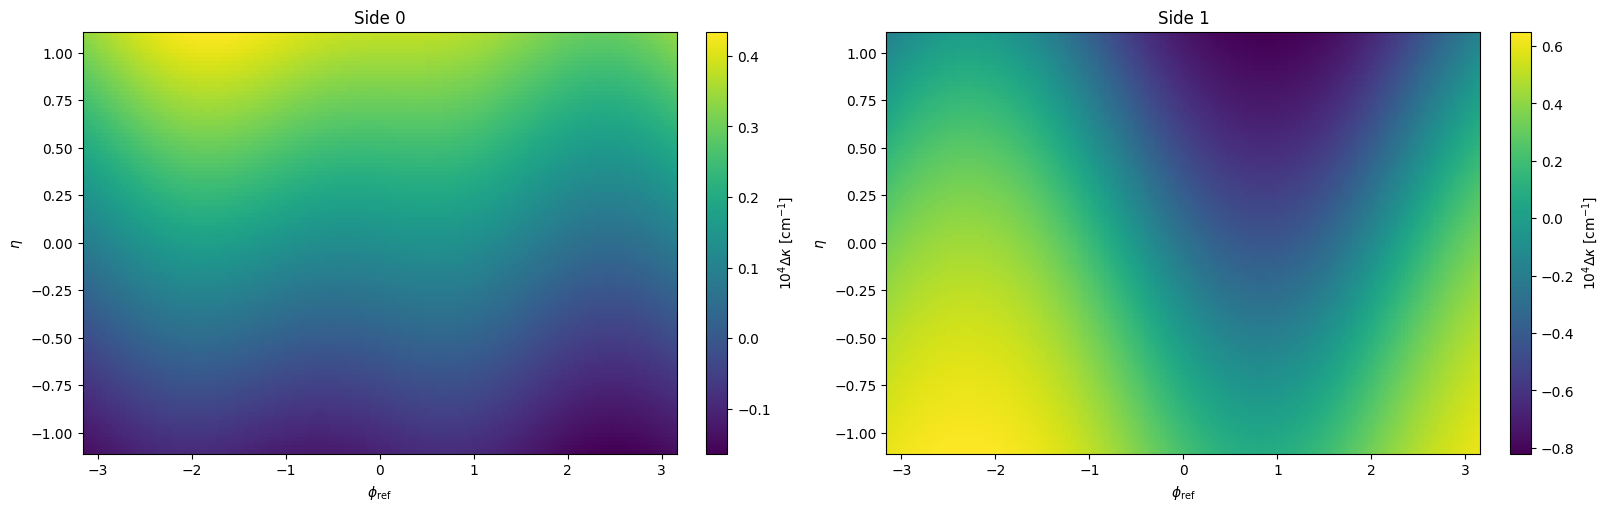

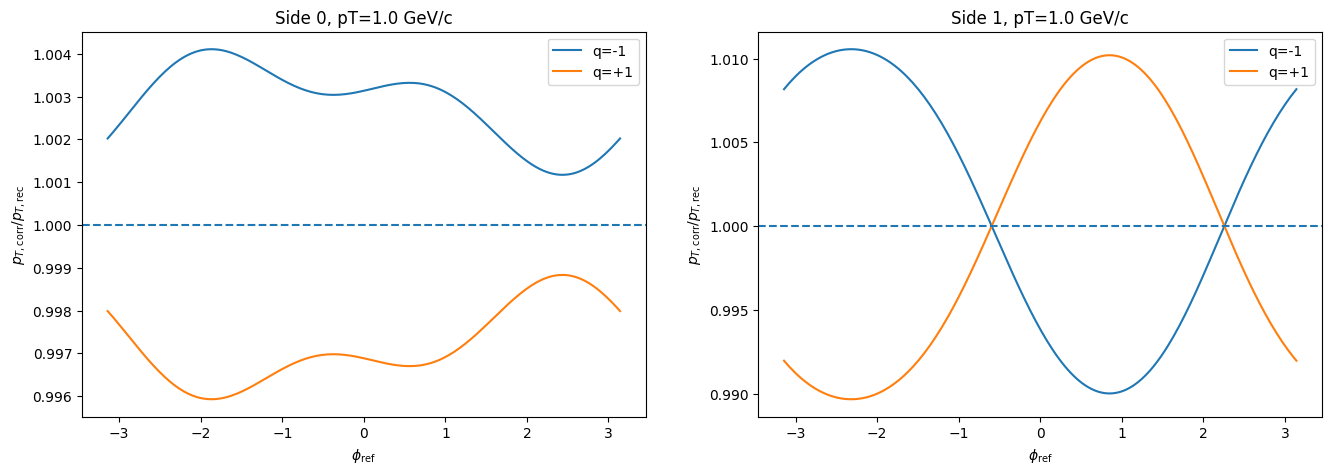

In [11]:
phi_values = np.linspace(-math.pi, math.pi, 180)
eta_values = np.linspace(-1.1, 1.1, 100)
phi_mesh, eta_mesh = np.meshgrid(phi_values, eta_values, indexing='xy')

figure, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)

for side in [0, 1]:
    delta = ensemble_delta_kappa(
        side,
        phi_mesh.ravel(),
        eta_mesh.ravel(),
    )['mean'].reshape(phi_mesh.shape)

    image = axes[side].pcolormesh(
        phi_values,
        eta_values,
        1e4 * delta,
        shading='auto',
    )
    axes[side].set_xlabel(r'$\phi_{\rm ref}$')
    axes[side].set_ylabel(r'$\eta$')
    axes[side].set_title(f'Side {side}')
    figure.colorbar(
        image,
        ax=axes[side],
        label=r'$10^4\Delta\kappa$ [cm$^{-1}$]',
    )

plt.show()

representative_pt = 1.0
representative_eta = 0.0
figure, axes = plt.subplots(1, 2, figsize=(16, 5))

for side in [0, 1]:
    delta = ensemble_delta_kappa(
        side,
        phi_values,
        np.full_like(phi_values, representative_eta),
    )['mean']

    for charge in [-1, 1]:
        scale = derived_momentum_scale(
            delta,
            np.full_like(phi_values, charge),
            np.full_like(phi_values, representative_pt),
        )
        axes[side].plot(phi_values, scale, label=f'q={charge:+d}')

    axes[side].axhline(1.0, linestyle='--')
    axes[side].set_xlabel(r'$\phi_{\rm ref}$')
    axes[side].set_ylabel(r'$p_{T,\rm corr}/p_{T,\rm rec}$')
    axes[side].set_title(f'Side {side}, pT={representative_pt} GeV/c')
    axes[side].legend()

plt.show()

side 0 before {'mean': 0.4998635877495589, 'width': 0.012815069874631553}
side 0 after  {'mean': 0.49982687211922155, 'width': 0.012740887796635082}
side 1 before {'mean': 0.49956464651018084, 'width': 0.012805087307719502}
side 1 after  {'mean': 0.49950321882423143, 'width': 0.012379960822085121}


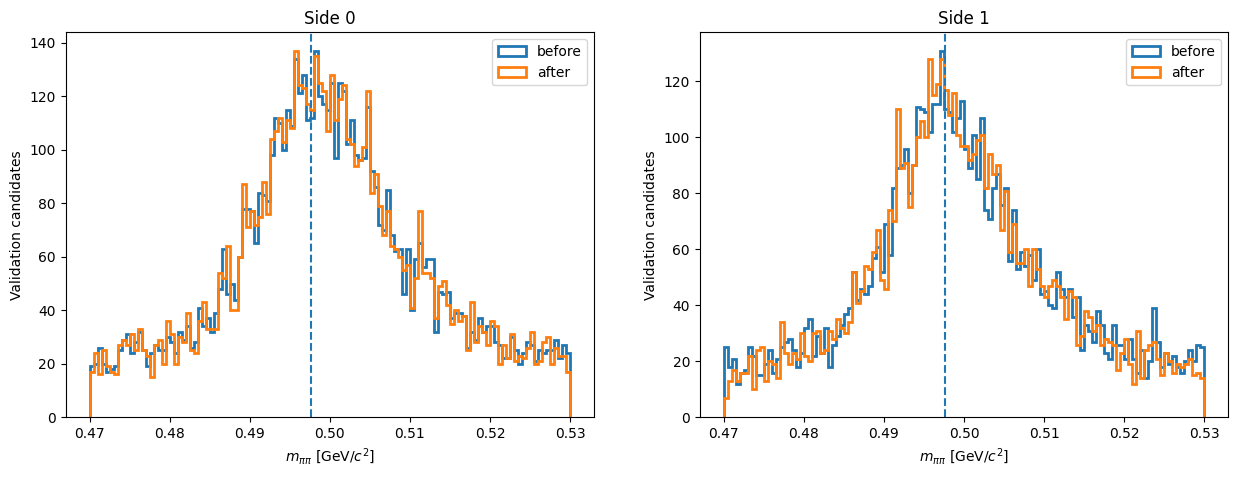

In [12]:
def corrected_mass_dataframe(frame, side, mass1=pion_mass, mass2=pion_mass):
    d1 = ensemble_delta_kappa(side, frame['phi1_ref'], frame['eta1'])['mean']
    d2 = ensemble_delta_kappa(side, frame['phi2_ref'], frame['eta2'])['mean']

    s1 = derived_momentum_scale(d1, frame['charge1'], frame['pt1'])
    s2 = derived_momentum_scale(d2, frame['charge2'], frame['pt2'])

    p1 = frame[['px1', 'py1', 'pz1']].to_numpy(float) * s1[:, None]
    p2 = frame[['px2', 'py2', 'pz2']].to_numpy(float) * s2[:, None]

    e1 = np.sqrt(np.sum(p1**2, axis=1) + mass1**2)
    e2 = np.sqrt(np.sum(p2**2, axis=1) + mass2**2)
    total = p1 + p2
    return np.sqrt(np.clip((e1 + e2)**2 - np.sum(total**2, axis=1), 0.0, None))

figure, axes = plt.subplots(1, 2, figsize=(15, 5))

for side in [0, 1]:
    frame = selected.loc[
        (selected['side'] == side)
        & (selected['entry_parity'] == validation_parity)
    ].copy()

    before = frame['mass_before'].to_numpy()
    after = corrected_mass_dataframe(frame, side)

    print('side', side, 'before', peak_metrics(before))
    print('side', side, 'after ', peak_metrics(after))

    axes[side].hist(
        before,
        bins=120,
        range=(validation_mass_minimum, validation_mass_maximum),
        histtype='step',
        linewidth=2,
        label='before',
    )
    axes[side].hist(
        after,
        bins=120,
        range=(validation_mass_minimum, validation_mass_maximum),
        histtype='step',
        linewidth=2,
        label='after',
    )
    axes[side].axvline(pdg_kshort_mass, linestyle='--')
    axes[side].set_xlabel(r'$m_{\pi\pi}$ [GeV/$c^2$]')
    axes[side].set_ylabel('Validation candidates')
    axes[side].set_title(f'Side {side}')
    axes[side].legend()

plt.show()


## Validation mass in \(K^0_S\) \(p_T\) bins

These plots use the untouched validation parity and are **not weighted**. The bins are:

\[
[0.5,0.8,1.1,1.4,1.8,2.2,3.0]\ {\rm GeV}/c.
\]

For each side and bin the notebook reports:

- number of validation candidates;
- peak mean before and after;
- peak width before and after;
- width ratio.

This is more informative than the inclusive mass alone because an additive curvature correction predicts a momentum-dependent fractional effect.


Wrote: output/k0s_momentum_scale_map_plots_cut03_new/k0s_mass_validation_by_pt_side0.pdf


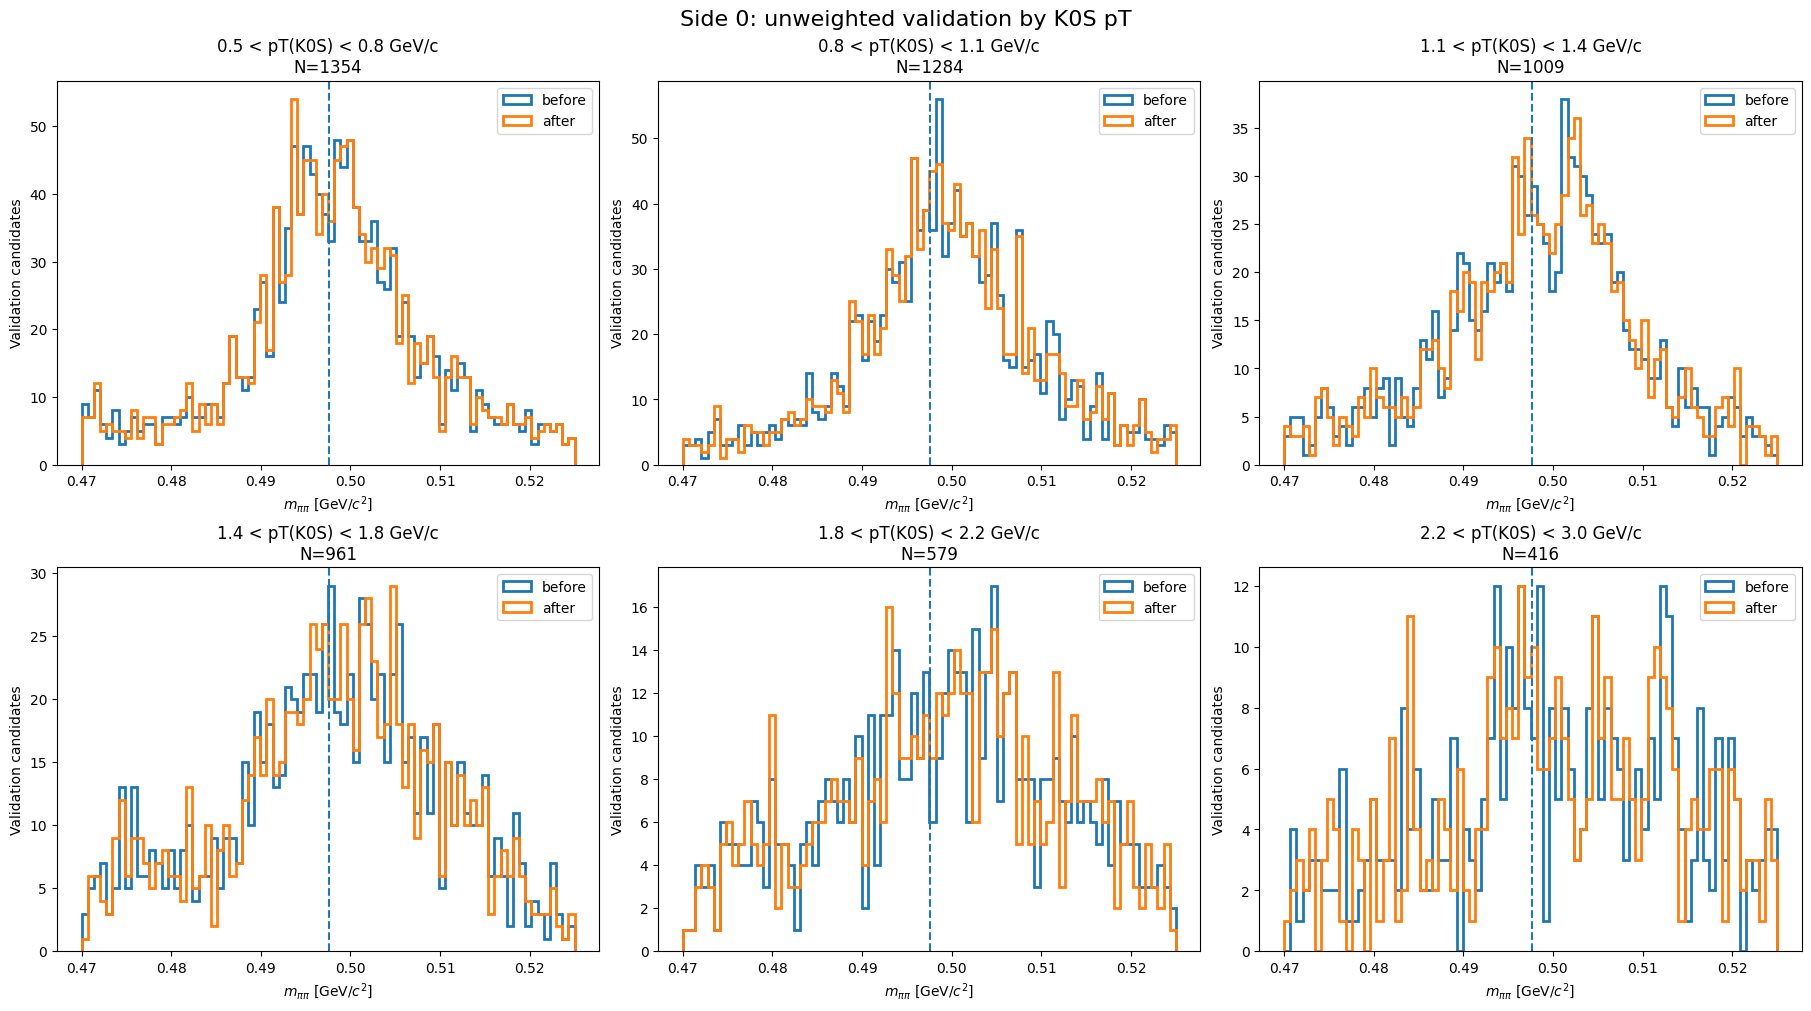

Wrote: output/k0s_momentum_scale_map_plots_cut03_new/k0s_mass_validation_by_pt_side1.pdf


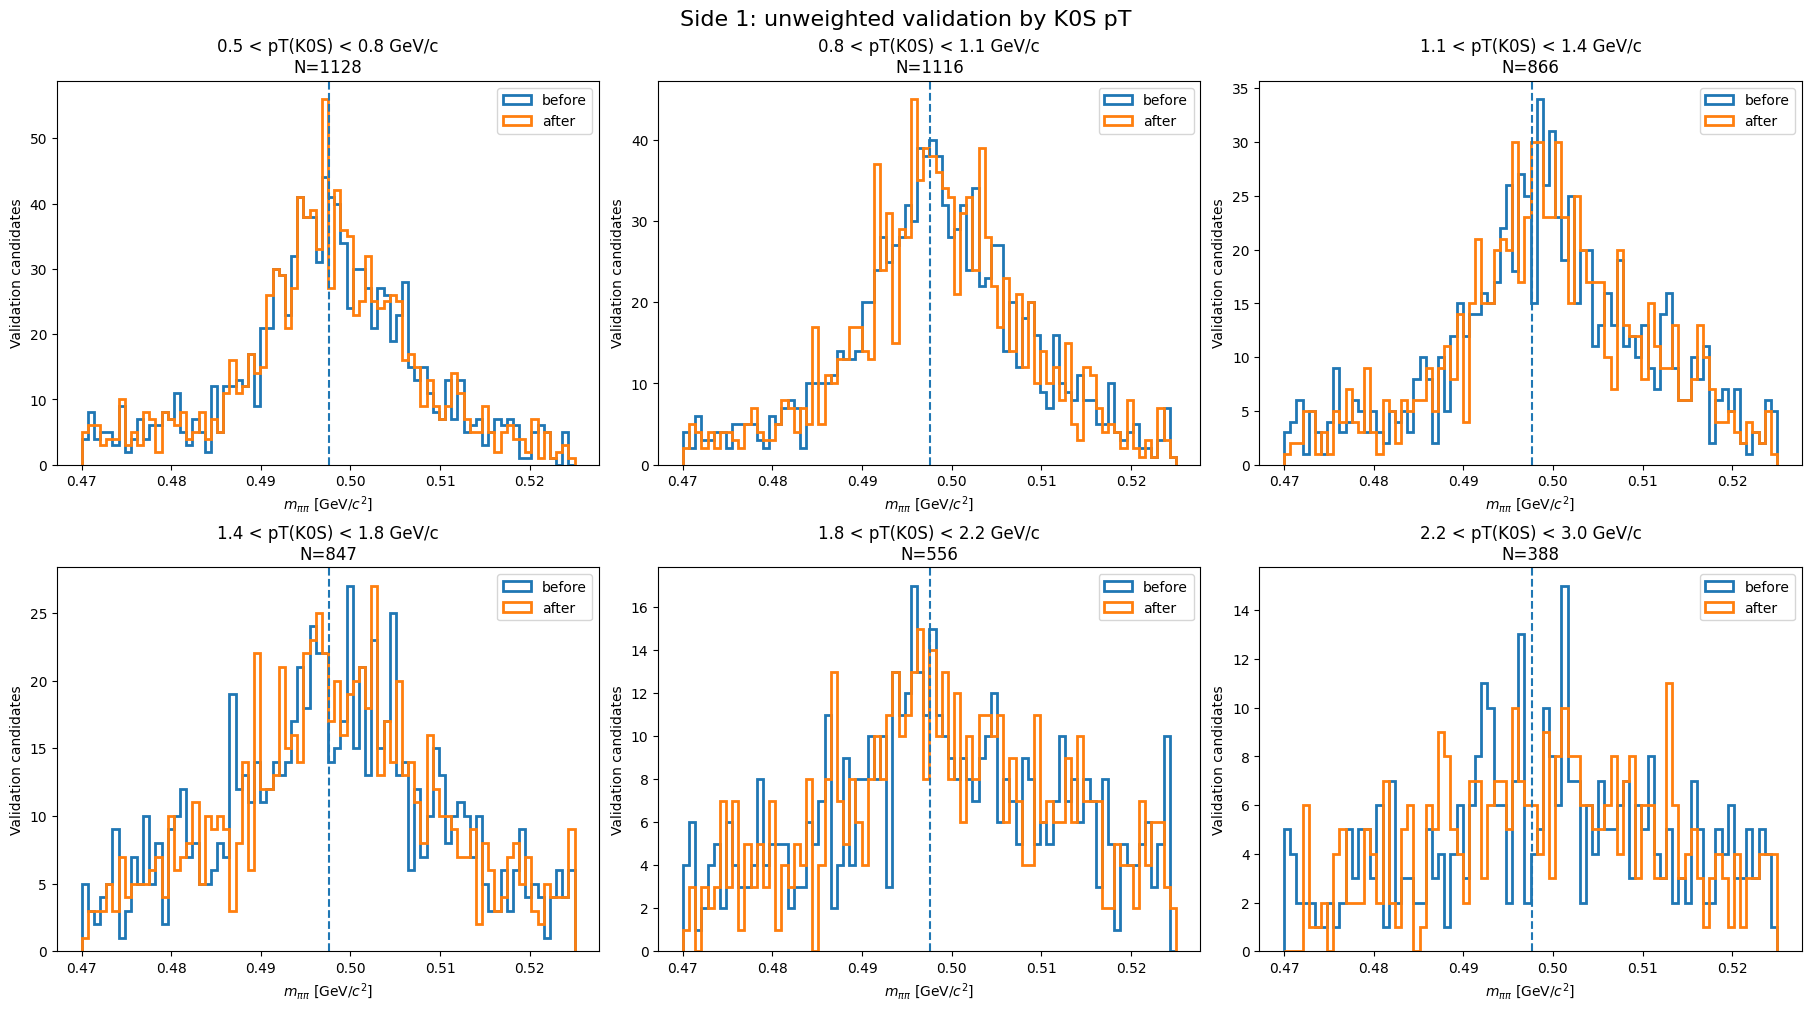

,side,pt_minimum,pt_maximum,pt_center,entries,mean_before,mean_after,width_before,width_after,width_ratio
0,0,0.5,0.8,0.65,1354,0.498471,0.498468,0.011565,0.011512,0.995437
1,0,0.8,1.1,0.95,1284,0.499902,0.499889,0.011115,0.011074,0.996287
2,0,1.1,1.4,1.25,1009,0.498947,0.498868,0.011579,0.011416,0.985935
3,0,1.4,1.8,1.60,961,0.498731,0.498714,0.012804,0.012710,0.992645
4,0,1.8,2.2,2.00,579,0.499944,0.499924,0.013864,0.013814,0.996359
5,0,2.2,3.0,2.60,416,0.502249,0.502018,0.014897,0.014741,0.989518
6,1,0.5,0.8,0.65,1128,0.497998,0.497921,0.011195,0.011039,0.986045
7,1,0.8,1.1,0.95,1116,0.498864,0.498845,0.010886,0.010649,0.978152
8,1,1.1,1.4,1.25,866,0.499864,0.499848,0.012021,0.011533,0.959407
9,1,1.4,1.8,1.60,847,0.498670,0.498752,0.013122,0.012587,0.959226


Wrote: output/k0s_momentum_scale_map_plots_cut03_new/k0s_mass_validation_pt_summary.pdf


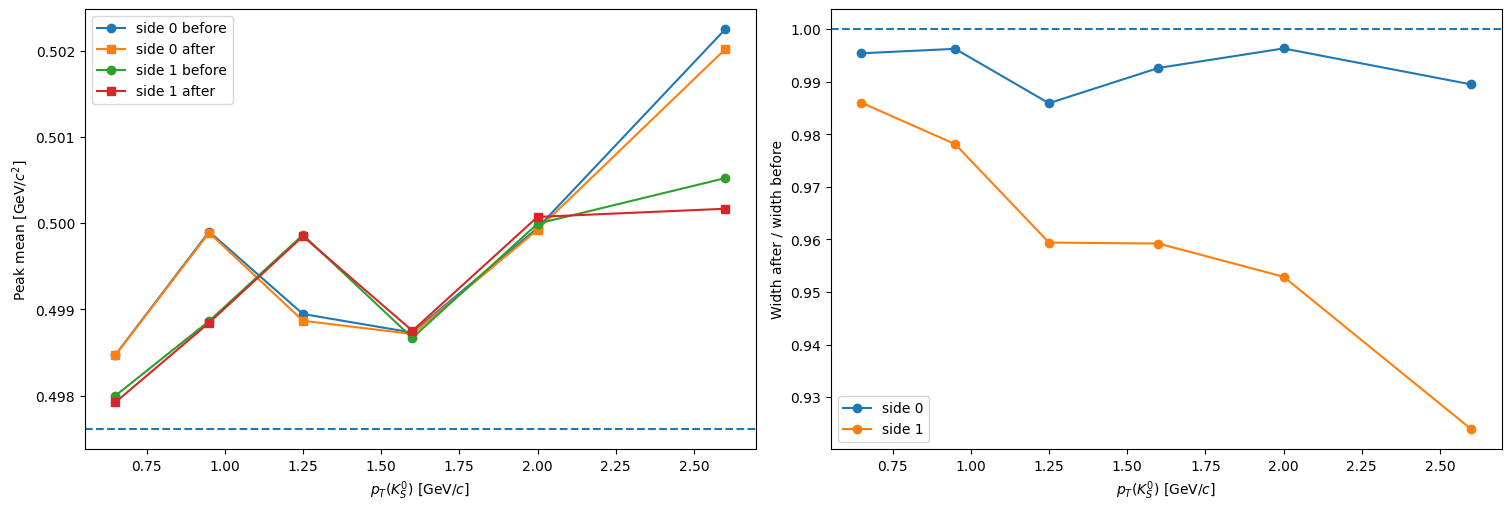

In [13]:

# ============================================================
# Unweighted validation mass in requested K0S-pT bins
# ============================================================

pt_validation_rows = []

for side in [0, 1]:
    frame = selected.loc[
        (selected["side"] == side)
        & (
            selected["entry_parity"]
            == validation_parity
        )
    ].copy()

    frame["mass_after"] = (
        corrected_mass_dataframe(
            frame,
            side,
        )
    )

    figure, axes = plt.subplots(
        2,
        3,
        figsize=(18, 10),
        constrained_layout=True,
    )

    for bin_index, axis in enumerate(
        axes.flat
    ):
        pt_minimum = (
            kshort_pt_bin_edges[
                bin_index
            ]
        )

        pt_maximum = (
            kshort_pt_bin_edges[
                bin_index + 1
            ]
        )

        in_bin = (
            (
                frame["kshort_pt"]
                >= pt_minimum
            )
            & (
                frame["kshort_pt"]
                < pt_maximum
            )
        )

        subset = frame.loc[in_bin]

        before = subset[
            "mass_before"
        ].to_numpy()

        after = subset[
            "mass_after"
        ].to_numpy()

        before_metrics = peak_metrics(
            before
        )

        after_metrics = peak_metrics(
            after
        )

        width_ratio = (
            after_metrics["width"]
            / before_metrics["width"]
            if (
                np.isfinite(
                    after_metrics["width"]
                )
                and np.isfinite(
                    before_metrics["width"]
                )
                and before_metrics[
                    "width"
                ] > 0
            )
            else np.nan
        )

        pt_validation_rows.append({
            "side": side,
            "pt_minimum": pt_minimum,
            "pt_maximum": pt_maximum,
            "pt_center": 0.5 * (
                pt_minimum + pt_maximum
            ),
            "entries": len(subset),
            "mean_before": (
                before_metrics["mean"]
            ),
            "mean_after": (
                after_metrics["mean"]
            ),
            "width_before": (
                before_metrics["width"]
            ),
            "width_after": (
                after_metrics["width"]
            ),
            "width_ratio": width_ratio,
        })

        axis.hist(
            before,
            bins=80,
            range=(
                0.47,
                0.525,
            ),
            histtype="step",
            linewidth=2,
            label="before",
        )

        axis.hist(
            after,
            bins=80,
            range=(
                0.47,
                0.525,
            ),
            histtype="step",
            linewidth=2,
            label="after",
        )

        axis.axvline(
            pdg_kshort_mass,
            linestyle="--",
        )

        axis.set_title(
            (
                f"{pt_minimum:.1f}"
                f" < pT(K0S) < "
                f"{pt_maximum:.1f} GeV/c\n"
                f"N={len(subset)}"
            )
        )

        axis.set_xlabel(
            r"$m_{\pi\pi}$ "
            r"[GeV/$c^2$]"
        )

        axis.set_ylabel(
            "Validation candidates"
        )

        axis.legend()

    figure.suptitle(
        (
            f"Side {side}: "
            "unweighted validation "
            "by K0S pT"
        ),
        fontsize=16,
    )

    output_plot = (
        work_dir
        / (
            "k0s_mass_validation_"
            f"by_pt_side{side}.pdf"
        )
    )

    figure.savefig(
        output_plot
    )

    print(
        "Wrote:",
        output_plot,
    )

    plt.show()


pt_validation_summary = pd.DataFrame(
    pt_validation_rows
)

pt_validation_summary.to_csv(
    work_dir
    / "k0s_mass_validation_by_pt.csv",
    index=False,
)

display(
    pt_validation_summary
)


# Summary trends.
figure, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5),
    constrained_layout=True,
)

for side in [0, 1]:
    subset = pt_validation_summary.loc[
        pt_validation_summary[
            "side"
        ] == side
    ]

    axes[0].plot(
        subset["pt_center"],
        subset["mean_before"],
        marker="o",
        label=f"side {side} before",
    )

    axes[0].plot(
        subset["pt_center"],
        subset["mean_after"],
        marker="s",
        label=f"side {side} after",
    )

    axes[1].plot(
        subset["pt_center"],
        subset["width_ratio"],
        marker="o",
        label=f"side {side}",
    )

axes[0].axhline(
    pdg_kshort_mass,
    linestyle="--",
)

axes[0].set_xlabel(
    r"$p_T(K^0_S)$ [GeV/$c$]"
)

axes[0].set_ylabel(
    r"Peak mean [GeV/$c^2$]"
)

axes[0].legend()

axes[1].axhline(
    1.0,
    linestyle="--",
)

axes[1].set_xlabel(
    r"$p_T(K^0_S)$ [GeV/$c$]"
)

axes[1].set_ylabel(
    "Width after / width before"
)

axes[1].legend()

summary_plot = (
    work_dir
    / "k0s_mass_validation_pt_summary.pdf"
)

figure.savefig(
    summary_plot
)

print(
    "Wrote:",
    summary_plot,
)

plt.show()


## Export maps

The physical map is two-dimensional in \((\phi_{\rm ref},\eta)\). The compatibility momentum-scale maps are derived from this common curvature map using measured \(p_T\) and charge; they are not separately fitted.

In [14]:
phi_edges = np.linspace(-math.pi, math.pi, 49)
eta_edges = np.linspace(-1.10, 1.10, 23)
pt_edges = np.array([
    0.20, 0.30, 0.40, 0.55, 0.70,
    0.90, 1.20, 1.50, 2.00, 3.00, 5.00,
])

phi_centers = 0.5 * (phi_edges[:-1] + phi_edges[1:])
eta_centers = 0.5 * (eta_edges[:-1] + eta_edges[1:])
pt_centers = 0.5 * (pt_edges[:-1] + pt_edges[1:])

rows = []

for side in [0, 1]:
    phi_grid, eta_grid = np.meshgrid(phi_centers, eta_centers, indexing='ij')
    stats = ensemble_delta_kappa(side, phi_grid.ravel(), eta_grid.ravel())

    for phi_ref, eta, delta, delta_std in zip(
        phi_grid.ravel(), eta_grid.ravel(), stats['mean'], stats['std']
    ):
        rows.append({
            'side': side,
            'phi_reference': phi_ref,
            'eta': eta,
            'delta_curvature': delta,
            'delta_curvature_ensemble_std': delta_std,
        })

curvature_grid = pd.DataFrame(rows)
curvature_grid.to_csv(work_dir / 'k0s_curvature_map_grid.csv', index=False)

if root is None:
    print('PyROOT unavailable; wrote CSV grid only.')
else:
    output = root.TFile.Open(str(work_dir / 'k0s_curvature_map.root'), 'RECREATE')

    root.TNamed(
        'method',
        (
            'K0S-constrained additive signed-curvature DNN; '
            f'B={magnetic_field_tesla} T; '
            f'reference radius={reference_radius_cm} cm'
        ),
    ).Write()

    for side in [0, 1]:
        side_dir = output.mkdir(f'side{side}')
        side_dir.cd()

        h_delta = root.TH2D(
            'h2_delta_curvature',
            'Additive curvature correction;#phi_{ref};#eta',
            len(phi_edges) - 1,
            array('d', phi_edges),
            len(eta_edges) - 1,
            array('d', eta_edges),
        )

        h_delta_std = root.TH2D(
            'h2_delta_curvature_ensemble_std',
            'Curvature ensemble spread;#phi_{ref};#eta',
            len(phi_edges) - 1,
            array('d', phi_edges),
            len(eta_edges) - 1,
            array('d', eta_edges),
        )

        subset = curvature_grid.loc[curvature_grid['side'] == side]

        for row in subset.itertuples(index=False):
            ibin = h_delta.FindBin(row.phi_reference, row.eta)
            h_delta.SetBinContent(ibin, row.delta_curvature)
            h_delta_std.SetBinContent(ibin, row.delta_curvature_ensemble_std)

        h_delta.Write()
        h_delta_std.Write()

        for charge in [-1, 1]:
            charge_dir = side_dir.mkdir('qplus' if charge > 0 else 'qminus')
            charge_dir.cd()

            h_scale = root.TH3D(
                'h3_momentum_scale',
                'Derived momentum scale;p_{T} [GeV/c];#phi_{ref};#eta',
                len(pt_edges) - 1,
                array('d', pt_edges),
                len(phi_edges) - 1,
                array('d', phi_edges),
                len(eta_edges) - 1,
                array('d', eta_edges),
            )

            for pt in pt_centers:
                for row in subset.itertuples(index=False):
                    scale = derived_momentum_scale(row.delta_curvature, charge, pt)
                    h_scale.SetBinContent(
                        h_scale.FindBin(pt, row.phi_reference, row.eta),
                        float(scale),
                    )

            h_scale.Write()

    output.Close()
    print('Wrote:', work_dir / 'k0s_curvature_map.root')

Wrote: output/k0s_momentum_scale_map_plots_cut03_new/k0s_curvature_map.root



## Convert to a standard vertex-coordinate momentum-scale map

The fitted physical map is

\[
\Delta\kappa_{\rm side}(\phi_{\rm ref},\eta),
\]

where \(\phi_{\rm ref}\) is the spatial azimuth at the TPC reference radius.

For ordinary analysis code it is often more convenient to use a map indexed by reconstructed track variables at the production vertex:

\[
s_{\rm side,q}(p_T,\phi_{\rm vertex},\eta).
\]

The conversion is:

1. start from the selected vertex position \((x_{\rm vertex},y_{\rm vertex})\);
2. propagate the measured helix with \(p_T\), charge, and \(B=1.4\) T to \(r_{\rm ref}\);
3. obtain \(\phi_{\rm ref}\);
4. evaluate \(\Delta\kappa_{\rm side}(\phi_{\rm ref},\eta)\);
5. calculate
   \[
   s=
   \frac{|\kappa_{\rm rec}|}
        {|\kappa_{\rm rec}+\Delta\kappa|}.
   \]

The standard ROOT file below uses the fixed beam position

\[
(x_{\rm beam},y_{\rm beam})=(0.158,0.285)\ {\rm cm}.
\]

It is directly appropriate for prompt tracks produced at the beam vertex.

For displaced \(K^0_S\), \(\Lambda\), \(\bar\Lambda\), and \(D^0\) daughters, use the per-track conversion function with the measured secondary-vertex coordinates. A fixed beam-origin TH3 map is only an approximation for displaced daughters.


In [15]:

# ============================================================
# Exact per-track converter:
# (phi at production vertex, eta, pT, charge, side, vertex x/y)
# -> phi_ref, delta-kappa, and momentum scale
# ============================================================

standard_map_origin_x_cm = 0.158
standard_map_origin_y_cm = 0.285

standard_vertex_map_root_file = (
    work_dir / "k0s_vertex_momentum_scale_map.root"
)

standard_vertex_map_csv_file = (
    work_dir / "k0s_vertex_momentum_scale_map_grid.csv"
)


def convert_vertex_track_to_momentum_scale(
    side,
    charge,
    pt,
    phi_vertex,
    eta,
    vertex_x_cm=standard_map_origin_x_cm,
    vertex_y_cm=standard_map_origin_y_cm,
):
    # Convert the side-specific delta-kappa map into a momentum
    # correction for arbitrary prompt or displaced tracks.

    pt_array = np.asarray(pt, dtype=np.float64)
    phi_array = np.asarray(phi_vertex, dtype=np.float64)
    eta_array = np.asarray(eta, dtype=np.float64)
    charge_array = np.asarray(charge, dtype=np.float64)
    vertex_x_array = np.asarray(vertex_x_cm, dtype=np.float64)
    vertex_y_array = np.asarray(vertex_y_cm, dtype=np.float64)

    broadcast_shape = np.broadcast(
        pt_array,
        phi_array,
        eta_array,
        charge_array,
        vertex_x_array,
        vertex_y_array,
    ).shape

    pt_array = np.broadcast_to(
        pt_array,
        broadcast_shape,
    ).ravel()

    phi_array = np.broadcast_to(
        phi_array,
        broadcast_shape,
    ).ravel()

    eta_array = np.broadcast_to(
        eta_array,
        broadcast_shape,
    ).ravel()

    charge_array = np.broadcast_to(
        charge_array,
        broadcast_shape,
    ).ravel()

    vertex_x_array = np.broadcast_to(
        vertex_x_array,
        broadcast_shape,
    ).ravel()

    vertex_y_array = np.broadcast_to(
        vertex_y_array,
        broadcast_shape,
    ).ravel()

    propagation = propagate_to_reference_radius(
        x0=vertex_x_array,
        y0=vertex_y_array,
        phi0=phi_array,
        pt=pt_array,
        charge=charge_array,
        rref=reference_radius_cm,
    )

    valid = propagation["valid"]

    phi_reference = propagation[
        "phi_position_ref"
    ]

    delta_curvature = np.full(
        pt_array.shape,
        np.nan,
        dtype=np.float64,
    )

    momentum_scale = np.full(
        pt_array.shape,
        np.nan,
        dtype=np.float64,
    )

    corrected_pt = np.full(
        pt_array.shape,
        np.nan,
        dtype=np.float64,
    )

    if np.any(valid):
        delta_curvature[valid] = (
            ensemble_delta_kappa(
                int(side),
                phi_reference[valid],
                eta_array[valid],
            )["mean"]
        )

        momentum_scale[valid] = (
            derived_momentum_scale(
                delta_curvature[valid],
                charge_array[valid],
                pt_array[valid],
            )
        )

        corrected_pt[valid] = (
            pt_array[valid]
            * momentum_scale[valid]
        )

    def restore_shape(values):
        values = values.reshape(
            broadcast_shape
        )

        if values.shape == ():
            return values.item()

        return values

    return {
        "valid": restore_shape(valid),
        "phi_reference": restore_shape(
            phi_reference
        ),
        "delta_curvature": restore_shape(
            delta_curvature
        ),
        "momentum_scale": restore_shape(
            momentum_scale
        ),
        "corrected_pt": restore_shape(
            corrected_pt
        ),
    }


example_conversion = (
    convert_vertex_track_to_momentum_scale(
        side=1,
        charge=+1,
        pt=1.0,
        phi_vertex=0.5,
        eta=0.3,
    )
)

print("Example conversion:", example_conversion)


Example conversion: {'valid': True, 'phi_reference': 0.39285202206228353, 'delta_curvature': -5.1405677368165925e-05, 'momentum_scale': 1.0123911072933143, 'corrected_pt': 1.0123911072933143}


In [16]:

# ============================================================
# Build the standard beam-origin map:
# pT x phi_vertex x eta, separately by side and charge
# ============================================================

vertex_phi_edges = np.linspace(
    -math.pi,
    math.pi,
    49,
    dtype=np.float64,
)

vertex_eta_edges = np.linspace(
    -1.10,
    1.10,
    23,
    dtype=np.float64,
)

vertex_pt_edges = np.array([
    0.20,
    0.30,
    0.40,
    0.55,
    0.70,
    0.90,
    1.20,
    1.50,
    2.00,
    3.00,
    5.00,
], dtype=np.float64)

vertex_phi_centers = 0.5 * (
    vertex_phi_edges[:-1]
    + vertex_phi_edges[1:]
)

vertex_eta_centers = 0.5 * (
    vertex_eta_edges[:-1]
    + vertex_eta_edges[1:]
)

vertex_pt_centers = 0.5 * (
    vertex_pt_edges[:-1]
    + vertex_pt_edges[1:]
)

vertex_map_rows = []

for side in [0, 1]:
    for charge in [-1, 1]:
        pt_grid, phi_grid, eta_grid = (
            np.meshgrid(
                vertex_pt_centers,
                vertex_phi_centers,
                vertex_eta_centers,
                indexing="ij",
            )
        )

        conversion = (
            convert_vertex_track_to_momentum_scale(
                side=side,
                charge=np.full(
                    pt_grid.size,
                    charge,
                    dtype=np.float64,
                ),
                pt=pt_grid.ravel(),
                phi_vertex=phi_grid.ravel(),
                eta=eta_grid.ravel(),
                vertex_x_cm=np.full(
                    pt_grid.size,
                    standard_map_origin_x_cm,
                ),
                vertex_y_cm=np.full(
                    pt_grid.size,
                    standard_map_origin_y_cm,
                ),
            )
        )

        for (
            pt_value,
            phi_vertex_value,
            eta_value,
            phi_reference_value,
            delta_value,
            scale_value,
            valid_value,
        ) in zip(
            pt_grid.ravel(),
            phi_grid.ravel(),
            eta_grid.ravel(),
            np.asarray(
                conversion["phi_reference"]
            ).ravel(),
            np.asarray(
                conversion["delta_curvature"]
            ).ravel(),
            np.asarray(
                conversion["momentum_scale"]
            ).ravel(),
            np.asarray(
                conversion["valid"]
            ).ravel(),
        ):
            vertex_map_rows.append({
                "side": side,
                "charge": charge,
                "pt": pt_value,
                "phi_vertex": (
                    phi_vertex_value
                ),
                "eta": eta_value,
                "phi_reference": (
                    phi_reference_value
                ),
                "delta_curvature": (
                    delta_value
                ),
                "momentum_scale": (
                    scale_value
                ),
                "valid": int(valid_value),
            })

vertex_momentum_scale_grid = pd.DataFrame(
    vertex_map_rows
)

vertex_momentum_scale_grid.to_csv(
    standard_vertex_map_csv_file,
    index=False,
)

print(
    "Wrote:",
    standard_vertex_map_csv_file,
)

display(
    vertex_momentum_scale_grid.loc[
        vertex_momentum_scale_grid[
            "valid"
        ].astype(bool)
    ]
    .groupby(
        ["side", "charge"]
    )[
        [
            "momentum_scale",
            "delta_curvature",
        ]
    ]
    .agg(
        ["min", "max", "mean", "std"]
    )
)


Wrote: output/k0s_momentum_scale_map_plots_cut03_new/k0s_vertex_momentum_scale_map_grid.csv


momentum_scale                               delta_curvature  \
                       min       max      mean       std             min   
side charge                                                                
0    -1           0.985454  1.041962  1.003847  0.006964       -0.000016   
      1           0.961264  1.014988  0.996276  0.006682       -0.000016   
1    -1           0.928465  1.065255  1.000665  0.015859       -0.000081   
      1           0.942259  1.083444  0.999841  0.016062       -0.000081   

                                           
                  max      mean       std  
side charge                                
0    -1      0.000042  0.000012  0.000015  
      1      0.000042  0.000012  0.000015  
1    -1      0.000064  0.000001  0.000039  
      1      0.000064  0.000001  0.000039

In [17]:

# ============================================================
# Write standard ROOT map for prompt tracks
#
# Paths:
#   side0/qminus/h3_momentum_scale
#   side0/qplus/h3_momentum_scale
#   side1/qminus/h3_momentum_scale
#   side1/qplus/h3_momentum_scale
#
# Axes:
#   X = pT
#   Y = phi at production vertex
#   Z = eta
# ============================================================

if root is None:
    print(
        "PyROOT unavailable; "
        "the standard vertex-map CSV was written, "
        "but the ROOT map was not."
    )
else:
    output = root.TFile.Open(
        str(
            standard_vertex_map_root_file
        ),
        "RECREATE",
    )

    if not output or output.IsZombie():
        raise OSError(
            "Could not create "
            f"{standard_vertex_map_root_file}"
        )

    root.TNamed(
        "method",
        (
            "Beam-origin standard momentum-scale map "
            "derived from charge-independent "
            "delta-kappa(phi_ref,eta); "
            f"B={magnetic_field_tesla} T; "
            f"reference radius="
            f"{reference_radius_cm} cm; "
            f"origin=("
            f"{standard_map_origin_x_cm},"
            f"{standard_map_origin_y_cm}) cm"
        ),
    ).Write()

    root.TNamed(
        "axis_definition",
        (
            "X=pT at production vertex [GeV/c]; "
            "Y=momentum phi at production vertex; "
            "Z=eta"
        ),
    ).Write()

    root.TNamed(
        "displaced_track_warning",
        (
            "This TH3 map assumes the fixed beam origin. "
            "For K0S, Lambda, anti-Lambda, or D0 daughters, "
            "use the exact per-track converter with the "
            "measured secondary-vertex x and y."
        ),
    ).Write()

    for side in [0, 1]:
        side_directory = output.mkdir(
            f"side{side}"
        )

        for charge in [-1, 1]:
            charge_directory = (
                side_directory.mkdir(
                    "qplus"
                    if charge > 0
                    else "qminus"
                )
            )

            charge_directory.cd()

            scale_histogram = root.TH3D(
                "h3_momentum_scale",
                (
                    "Momentum scale at production vertex;"
                    "p_{T} [GeV/c];"
                    "#phi_{vertex};"
                    "#eta"
                ),
                len(vertex_pt_edges) - 1,
                array(
                    "d",
                    vertex_pt_edges,
                ),
                len(vertex_phi_edges) - 1,
                array(
                    "d",
                    vertex_phi_edges,
                ),
                len(vertex_eta_edges) - 1,
                array(
                    "d",
                    vertex_eta_edges,
                ),
            )

            phi_reference_histogram = (
                root.TH3D(
                    "h3_phi_reference",
                    (
                        "Propagated reference azimuth;"
                        "p_{T} [GeV/c];"
                        "#phi_{vertex};"
                        "#eta"
                    ),
                    len(vertex_pt_edges) - 1,
                    array(
                        "d",
                        vertex_pt_edges,
                    ),
                    len(vertex_phi_edges) - 1,
                    array(
                        "d",
                        vertex_phi_edges,
                    ),
                    len(vertex_eta_edges) - 1,
                    array(
                        "d",
                        vertex_eta_edges,
                    ),
                )
            )

            delta_curvature_histogram = (
                root.TH3D(
                    "h3_delta_curvature",
                    (
                        "Delta curvature after propagation;"
                        "p_{T} [GeV/c];"
                        "#phi_{vertex};"
                        "#eta"
                    ),
                    len(vertex_pt_edges) - 1,
                    array(
                        "d",
                        vertex_pt_edges,
                    ),
                    len(vertex_phi_edges) - 1,
                    array(
                        "d",
                        vertex_phi_edges,
                    ),
                    len(vertex_eta_edges) - 1,
                    array(
                        "d",
                        vertex_eta_edges,
                    ),
                )
            )

            subset = (
                vertex_momentum_scale_grid.loc[
                    (
                        vertex_momentum_scale_grid[
                            "side"
                        ] == side
                    )
                    & (
                        vertex_momentum_scale_grid[
                            "charge"
                        ] == charge
                    )
                    & (
                        vertex_momentum_scale_grid[
                            "valid"
                        ].astype(bool)
                    )
                ]
            )

            for row in subset.itertuples(
                index=False
            ):
                global_bin = (
                    scale_histogram.FindBin(
                        row.pt,
                        row.phi_vertex,
                        row.eta,
                    )
                )

                scale_histogram.SetBinContent(
                    global_bin,
                    float(
                        row.momentum_scale
                    ),
                )

                phi_reference_histogram.SetBinContent(
                    global_bin,
                    float(
                        row.phi_reference
                    ),
                )

                delta_curvature_histogram.SetBinContent(
                    global_bin,
                    float(
                        row.delta_curvature
                    ),
                )

            scale_histogram.Write()
            phi_reference_histogram.Write()
            delta_curvature_histogram.Write()

    output.Close()

    print(
        "Wrote:",
        standard_vertex_map_root_file,
    )


Wrote: output/k0s_momentum_scale_map_plots_cut03_new/k0s_vertex_momentum_scale_map.root



### Applying the map to displaced particles

For a prompt particle produced at the beam vertex, use the exported standard TH3 map directly:

```text
side{side}/{qminus|qplus}/h3_momentum_scale
```

with \((p_T,\phi_{\rm vertex},\eta)\).

For a displaced daughter, evaluate the exact converter using its reconstructed secondary vertex:

```python
result = convert_vertex_track_to_momentum_scale(
    side=side,
    charge=charge,
    pt=pt,
    phi_vertex=phi_at_secondary_vertex,
    eta=eta,
    vertex_x_cm=secondary_vertex_x,
    vertex_y_cm=secondary_vertex_y,
)

pt_corrected = result["corrected_pt"]
scale = result["momentum_scale"]
```

This is the correct method for the planned \(\Lambda\) and \(\bar\Lambda\) validation.


## Lambda and anti-Lambda validation

Train only with \(K^0_S\), then apply the same side-specific \(\Delta\kappa(\phi_{\rm ref},\eta)\) to

\[
\Lambda\to p\pi^-,
\qquad
\bar\Lambda\to\bar p\pi^+.
\]

For every daughter, propagate to the same reference radius, evaluate the same charge-independent curvature correction, derive the momentum correction from measured charge and \(p_T\), and recalculate the mass using the proton/pion assignment. The current K0S CSV exporter filters out Lambda rows, so this validation needs a companion Lambda CSV exporter.